# Multivariate Matrix Profile Anomaly Detection with MSTUMP

This notebook is the multivariate extension of the Matrix Profile experiments used in the thesis. The earlier work focused on univariate time series, but IoT systems are rarely described by a single signal. In practice, several measurements are collected at the same time, and some faults are easier to understand when the sensors are considered together.

The experiment uses a synthetic IoT dataset with three related variables: temperature, humidity, and power consumption. Synthetic data is used here on purpose, because it makes it possible to control the normal behaviour of the system and to inject anomalies with known start and end times.

The main goal is to compare ordinary univariate Matrix Profile detection with the multidimensional Matrix Profile computed by MSTUMP. The anomaly set includes simple one-sensor changes, system-wide changes, and relationship anomalies where the individual signals may still look realistic but their joint behaviour is wrong.

Three groups of methods are compared:

1. STUMP applied separately to each sensor.
2. Aggregated univariate scores across the three sensors.
3. MSTUMP applied to the multivariate signal.


## 1. Imports and Configuration

The notebook starts by loading the libraries used for data generation, plotting, Matrix Profile computation, and evaluation. I also set the main experiment parameters in one place so that the rest of the notebook is easier to follow and reproduce.

The dataset covers 14 days with one measurement per minute, so each sensor contains 20,160 observations. A fixed random seed is used for both the normal data and the injected anomalies. This is important because otherwise the anomaly locations and magnitudes would change each time the notebook is executed.

The main subsequence length is `m = 360`, which corresponds to 6 hours. This window is long enough to capture part of the daily operating behaviour, but it is still practical for MSTUMP. Longer windows are included later as an optional sensitivity check because Matrix Profile results can change noticeably when `m` changes.

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    import stumpy
except ImportError as exc:
    raise ImportError(
        "STUMPY is required for this notebook. Install it with: "
        "pip install stumpy scikit-learn pandas numpy matplotlib scipy"
    ) from exc

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

BASE_DIR = Path(r"C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset")
PLOTS_DIR = BASE_DIR / "plots" / "multivariate_mstump"
OUTPUTS_DIR = BASE_DIR / "outputs" / "multivariate_mstump"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLING_FREQUENCY = "1min"
MINUTES_PER_DAY = 24 * 60
N_DAYS = 14
N_SAMPLES = N_DAYS * MINUTES_PER_DAY
START_TIME = "2024-01-01 00:00:00"

WINDOW_SIZE_MAIN = 720  # 12 hours at 1-minute sampling
EXTRA_WINDOW_SIZES = [360, 1440]  # 6 hours and 24 hours
RUN_EXTRA_WINDOWS = True  # Set True to run the optional slower comparison section.

SENSOR_COLUMNS = [
    "temperature",
    "humidity",
    "power_consumption",
]

SENSOR_LABELS = {
    "temperature": "temperature",
    "humidity": "humidity",
    "power_consumption": "power",
}

datetime_index = pd.date_range(
    start=START_TIME,
    periods=N_SAMPLES,
    freq=SAMPLING_FREQUENCY,
)

plt.rcParams.update(
    {
        "figure.figsize": (14, 8),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

print(f"Experiment directory: {BASE_DIR}")
print(f"Samples: {N_SAMPLES:,} ({N_DAYS} days at {SAMPLING_FREQUENCY})")
print(f"Main Matrix Profile window m: {WINDOW_SIZE_MAIN}")
print(f"Sensor dimensions: {len(SENSOR_COLUMNS)}")


Experiment directory: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset
Samples: 20,160 (14 days at 1min)
Main Matrix Profile window m: 720
Sensor dimensions: 3


## 2. Generation of the Normal Multivariate IoT Dataset

The dataset is generated synthetically so that the normal operating pattern is known. This is useful for a thesis experiment because real multivariate IoT datasets often lack precise labels, especially for relationship-based anomalies.

The normal dataset contains three sensor streams:

| Sensor | Normal behaviour | Role in the experiment |
|---|---|---|
| `temperature` | Daily sinusoidal pattern with a small drift and noise | Main environmental signal |
| `humidity` | Daily pattern in the opposite direction from temperature | Creates a clear cross-sensor relationship |
| `power_consumption` | Daytime load pattern with some temperature dependence | Represents system activity |

The three variables are not meant to be independent. Humidity is designed to decrease when temperature rises, while power consumption follows the daily load and is also affected slightly by temperature. These links are useful because MSTUMP should have a chance to detect anomalies that are not obvious from one sensor alone.

Before adding anomalies, the normal signals are plotted as a basic check that the generated behaviour looks reasonable.

,temperature,humidity,power_consumption
2024-01-01 00:00:00,18.601589,61.928167,0.992693
2024-01-01 00:01:00,17.981120,61.945111,0.964501
2024-01-01 00:02:00,18.771530,65.138859,1.035630
2024-01-01 00:03:00,18.841863,61.757878,0.880065
2024-01-01 00:04:00,17.525494,63.381631,0.956780


,count,mean,std,min,25%,50%,75%,max
temperature,20160.0,22.402576,3.584715,15.985872,18.910499,22.402966,25.921642,29.128853
humidity,20160.0,54.904028,7.189276,40.825096,47.928267,54.904336,61.866657,68.801054
power_consumption,20160.0,1.323336,0.316504,0.699596,1.027109,1.265941,1.636794,2.045546


Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\normal_multivariate_dataset.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\normal_multivariate_dataset.pdf


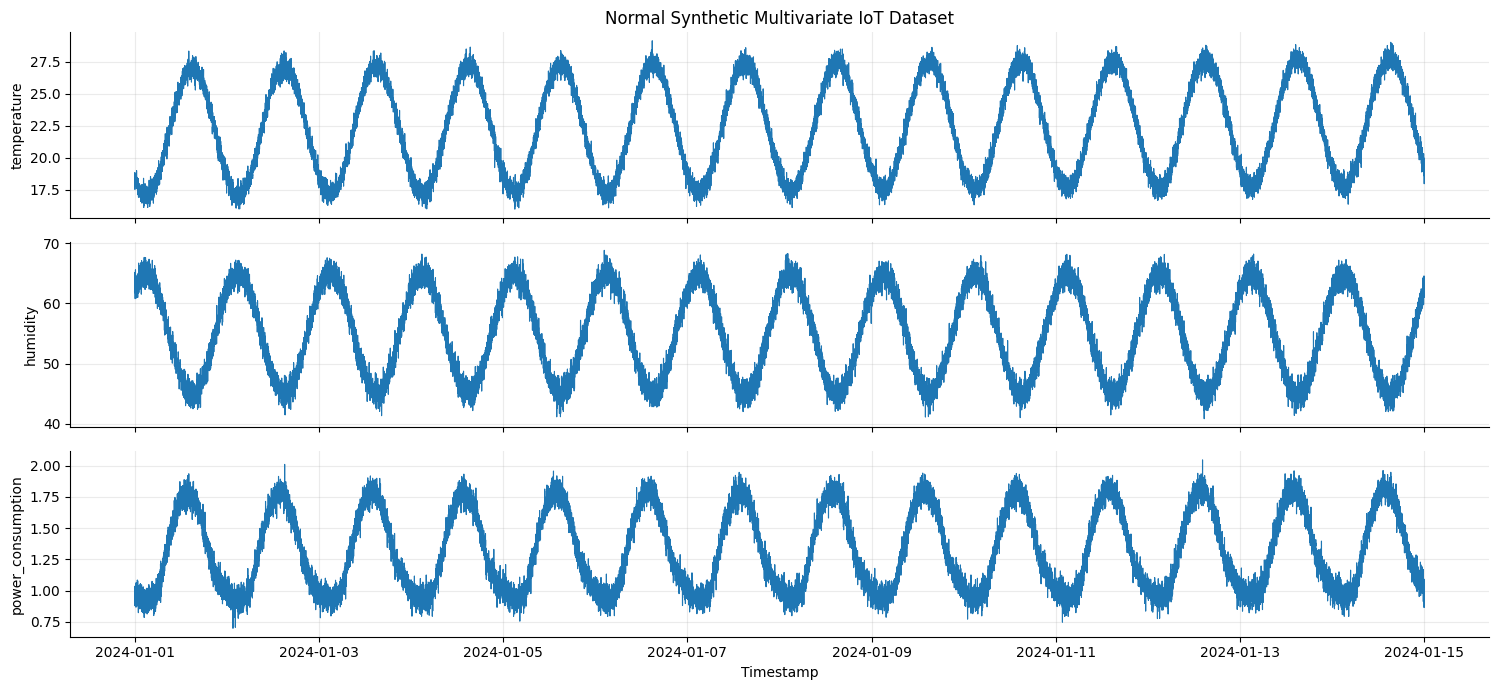

In [2]:
def generate_normal_multivariate_iot_data(
    n_samples: int,
    index: pd.DatetimeIndex,
    rng: np.random.Generator,
) -> pd.DataFrame:
    """
    Generate a synthetic multivariate IoT dataset under normal operating conditions.

    The dataset contains three related sensor streams:
    - temperature
    - humidity
    - power_consumption

    The signals are not independent. Humidity is designed to be inversely related
    to temperature, while power consumption is partly affected by the daily
    operating/load pattern and by temperature.
    """

    minute_of_day = np.arange(n_samples) % MINUTES_PER_DAY

    daily_temperature_wave = np.sin(
        2 * np.pi * (minute_of_day - 9 * 60) / MINUTES_PER_DAY
    )

    mild_drift = np.linspace(0.0, 0.8, n_samples)

    temperature = (
        22.0
        + 5.0 * daily_temperature_wave
        + mild_drift
        + rng.normal(0.0, 0.45, n_samples)
    )

    humidity = (
        55.0
        - 10.0 * daily_temperature_wave
        - 0.25 * mild_drift
        + rng.normal(0.0, 1.2, n_samples)
    )
    humidity = np.clip(humidity, 20.0, 95.0)

    daylight_load = np.clip(
        np.sin(np.pi * (minute_of_day - 6 * 60) / (14 * 60)),
        0.0,
        None,
    )

    power_consumption = (
        1.15
        + 0.42 * daylight_load
        + 0.045 * (temperature - 22.0)
        + rng.normal(0.0, 0.055, n_samples)
    )
    power_consumption = np.clip(power_consumption, 0.35, None)

    return pd.DataFrame(
        {
            "temperature": temperature,
            "humidity": humidity,
            "power_consumption": power_consumption,
        },
        index=index,
    )


rng_data = np.random.default_rng(RANDOM_SEED)
df_normal = generate_normal_multivariate_iot_data(N_SAMPLES, datetime_index, rng_data)

display(df_normal.head())
display(df_normal.describe().T)


def save_figure(fig: plt.Figure, name: str) -> None:
    """
    Save a matplotlib figure in both PNG and PDF format.

    PNG is useful for quick viewing, while PDF is useful for thesis writing
    because it keeps the figure quality high when inserted into LaTeX/Overleaf.
    """

    png_path = PLOTS_DIR / f"{name}.png"
    pdf_path = PLOTS_DIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=200, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


def plot_sensor_panel(df: pd.DataFrame, title: str) -> plt.Figure:
    """
    Plot all sensor streams in separate aligned panels.

    Each sensor is shown in its own subplot, but all subplots share the same
    time axis. This makes it easier to compare the behaviour of the three
    signals over the same period.
    """

    fig, axes = plt.subplots(
        len(SENSOR_COLUMNS),
        1,
        figsize=(15, 7),
        sharex=True,
    )

    if len(SENSOR_COLUMNS) == 1:
        axes = [axes]

    for ax, sensor in zip(axes, SENSOR_COLUMNS):
        ax.plot(df.index, df[sensor], linewidth=0.8, color="tab:blue")
        ax.set_ylabel(sensor)

    axes[0].set_title(title)
    axes[-1].set_xlabel("Timestamp")
    fig.tight_layout()
    return fig


fig = plot_sensor_panel(df_normal, "Normal Synthetic Multivariate IoT Dataset")
save_figure(fig, "normal_multivariate_dataset")
plt.show()


**Summary**

The generated normal data has the expected structure. Temperature follows a strong daily rhythm, humidity moves in the opposite direction, and power consumption is higher during active daytime periods.

This gives the dataset both individual sensor patterns and relationships across sensors. That combination is important for the later comparison between univariate STUMP and multivariate MSTUMP.

## 3. Injection of Known Anomalies

After generating the normal data, anomalies are injected into a copy of the dataset. Because the data is synthetic, each injected event can be stored with its exact timestamp range. These labels are later used for ROC AUC, PR AUC, precision, recall, F1-score, and event-level coverage.

The anomaly set is deliberately mixed. Some events are easy single-sensor faults, while others involve several sensors or break the normal relationship between variables. This makes the experiment more realistic than testing only one anomaly shape.

The injected categories are:

| Anomaly type | What changes | Why it is included |
|---|---|---|
| Single-sensor spikes | One sensor has a sudden one-point abnormal value | Tests short sensor faults or measurement errors |
| Single-sensor level shifts | One sensor stays shifted for several hours | Tests sustained abnormal behaviour in one channel |
| Multisensor system anomalies | Temperature, humidity, and power change together | Simulates a broader abnormal operating state |
| Correlation-breaking anomalies | A normal relationship between sensors is disrupted | Tests the main motivation for using a multivariate method |

The anomaly intervals are kept non-overlapping. Each event is stored in `anomaly_metadata`, and every timestamp inside an event is marked as anomalous in `y_true`.

In [3]:
def find_non_overlapping_interval(
    duration: int,
    blocked: np.ndarray,
    rng: np.random.Generator,
    min_start: int = 0,
    max_start: int | None = None,
    guard_gap: int = 30,
    max_attempts: int = 10_000,
) -> tuple[int, int]:
    """
    Find a time interval where a new anomaly can be placed without overlapping
    with previously injected anomalies.
    """

    n = len(blocked)
    if max_start is None:
        max_start = n - duration
    max_start = min(max_start, n - duration)

    if max_start < min_start:
        raise ValueError("No valid start positions for the requested duration.")

    for _ in range(max_attempts):
        start_idx = int(rng.integers(min_start, max_start + 1))
        end_idx_exclusive = start_idx + duration
        left = max(0, start_idx - guard_gap)
        right = min(n, end_idx_exclusive + guard_gap)
        if not blocked[left:right].any():
            return start_idx, end_idx_exclusive

    for start_idx in range(min_start, max_start + 1):
        end_idx_exclusive = start_idx + duration
        left = max(0, start_idx - guard_gap)
        right = min(n, end_idx_exclusive + guard_gap)
        if not blocked[left:right].any():
            return start_idx, end_idx_exclusive

    if guard_gap > 0:
        for _ in range(max_attempts):
            start_idx = int(rng.integers(min_start, max_start + 1))
            end_idx_exclusive = start_idx + duration
            if not blocked[start_idx:end_idx_exclusive].any():
                return start_idx, end_idx_exclusive

        for start_idx in range(min_start, max_start + 1):
            end_idx_exclusive = start_idx + duration
            if not blocked[start_idx:end_idx_exclusive].any():
                return start_idx, end_idx_exclusive

    raise RuntimeError("Could not find a non-overlapping anomaly interval.")


def mark_anomaly(
    y_true: np.ndarray,
    blocked: np.ndarray,
    records: list[dict],
    anomaly_id: str,
    anomaly_type: str,
    affected_sensor_or_relationship: str,
    start_idx: int,
    end_idx_exclusive: int,
    description: str,
    guard_gap: int = 30,
) -> None:
    """
    Mark an injected anomaly in the ground-truth label array and store metadata.
    """

    y_true[start_idx:end_idx_exclusive] = 1
    blocked[start_idx:end_idx_exclusive] = True

    end_idx_inclusive = end_idx_exclusive - 1
    records.append(
        {
            "anomaly_id": anomaly_id,
            "type": anomaly_type,
            "affected_sensor_or_relationship": affected_sensor_or_relationship,
            "start_time": datetime_index[start_idx],
            "end_time": datetime_index[end_idx_inclusive],
            "start_idx": start_idx,
            "end_idx": end_idx_inclusive,
            "duration_minutes": end_idx_exclusive - start_idx,
            "description": description,
        }
    )


def inject_single_sensor_spikes(
    df: pd.DataFrame,
    y_true: np.ndarray,
    blocked: np.ndarray,
    records: list[dict],
    rng: np.random.Generator,
    n_events: int = 20,
) -> None:
    """
    Inject short one-timestamp anomalies into individual sensors.
    """

    event_sensors = []
    while len(event_sensors) < n_events:
        event_sensors.extend(SENSOR_COLUMNS)
    event_sensors = event_sensors[:n_events]
    rng.shuffle(event_sensors)

    for event_number, sensor in enumerate(event_sensors, start=1):
        start_idx, end_idx_exclusive = find_non_overlapping_interval(
            duration=1,
            blocked=blocked,
            rng=rng,
            min_start=MINUTES_PER_DAY // 2,
            max_start=N_SAMPLES - MINUTES_PER_DAY // 2,
            guard_gap=45,
        )

        old_value = float(df.iloc[start_idx][sensor])

        if sensor == "temperature":
            delta = rng.choice([-1.0, 1.0]) * rng.uniform(6.0, 10.0)
            df.iloc[start_idx, df.columns.get_loc(sensor)] = old_value + delta
            description = f"Temperature one-minute spike of {delta:+.2f} deg C."

        elif sensor == "humidity":
            delta = rng.choice([-1.0, 1.0]) * rng.uniform(15.0, 25.0)
            new_value = np.clip(old_value + delta, 0.0, 100.0)
            df.iloc[start_idx, df.columns.get_loc(sensor)] = new_value
            description = f"Humidity one-minute spike of {delta:+.2f} percentage points."

        elif sensor == "power_consumption":
            pct = rng.uniform(0.25, 0.50)
            sign = rng.choice([-1.0, 1.0])
            new_value = max(0.05, old_value * (1.0 + sign * pct))
            df.iloc[start_idx, df.columns.get_loc(sensor)] = new_value
            description = f"Power one-minute {'increase' if sign > 0 else 'drop'} of {pct:.0%}."

        mark_anomaly(
            y_true=y_true,
            blocked=blocked,
            records=records,
            anomaly_id=f"A1_{event_number:02d}",
            anomaly_type="single_sensor_spike",
            affected_sensor_or_relationship=sensor,
            start_idx=start_idx,
            end_idx_exclusive=end_idx_exclusive,
            description=description,
            guard_gap=45,
        )


def inject_single_sensor_level_shifts(
    df: pd.DataFrame,
    y_true: np.ndarray,
    blocked: np.ndarray,
    records: list[dict],
    rng: np.random.Generator,
    n_events: int = 4,
) -> None:
    """
    Inject sustained level shifts that affect one sensor at a time.
    """

    level_shift_sensors = []
    while len(level_shift_sensors) < n_events:
        level_shift_sensors.extend(SENSOR_COLUMNS)
    level_shift_sensors = level_shift_sensors[:n_events]
    rng.shuffle(level_shift_sensors)

    for event_number, sensor in enumerate(level_shift_sensors, start=1):
        duration = int(rng.integers(6 * 60, 18 * 60 + 1))
        start_idx, end_idx_exclusive = find_non_overlapping_interval(
            duration=duration,
            blocked=blocked,
            rng=rng,
            min_start=MINUTES_PER_DAY,
            max_start=N_SAMPLES - MINUTES_PER_DAY - duration,
            guard_gap=90,
        )
        rows = slice(start_idx, end_idx_exclusive)

        if sensor == "temperature":
            shift = rng.uniform(2.0, 4.0)
            df.iloc[rows, df.columns.get_loc(sensor)] += shift
            description = f"Temperature level shift of +{shift:.2f} deg C."

        elif sensor == "humidity":
            shift = -rng.uniform(10.0, 20.0)
            df.iloc[rows, df.columns.get_loc(sensor)] = np.clip(
                df.iloc[rows, df.columns.get_loc(sensor)] + shift,
                0.0,
                100.0,
            )
            description = f"Humidity level shift of {shift:.2f} percentage points."

        elif sensor == "power_consumption":
            pct = rng.uniform(0.15, 0.30)
            df.iloc[rows, df.columns.get_loc(sensor)] *= 1.0 + pct
            description = f"Power level shift of +{pct:.0%}."

        mark_anomaly(
            y_true=y_true,
            blocked=blocked,
            records=records,
            anomaly_id=f"A2_{event_number:02d}",
            anomaly_type="single_sensor_level_shift",
            affected_sensor_or_relationship=sensor,
            start_idx=start_idx,
            end_idx_exclusive=end_idx_exclusive,
            description=description,
            guard_gap=90,
        )


def inject_multisensor_system_anomalies(
    df: pd.DataFrame,
    y_true: np.ndarray,
    blocked: np.ndarray,
    records: list[dict],
    rng: np.random.Generator,
    n_events: int = 3,
) -> None:
    """
    Inject physically meaningful system anomalies across all three sensors.
    """

    for event_number in range(1, n_events + 1):
        duration = int(rng.integers(6 * 60, 12 * 60 + 1))
        start_idx, end_idx_exclusive = find_non_overlapping_interval(
            duration=duration,
            blocked=blocked,
            rng=rng,
            min_start=MINUTES_PER_DAY,
            max_start=N_SAMPLES - MINUTES_PER_DAY - duration,
            guard_gap=120,
        )
        rows = slice(start_idx, end_idx_exclusive)

        temp_shift = rng.uniform(2.5, 4.5)
        humidity_shift = -rng.uniform(8.0, 15.0)
        power_pct = rng.uniform(0.18, 0.35)

        df.iloc[rows, df.columns.get_loc("temperature")] += temp_shift
        df.iloc[rows, df.columns.get_loc("humidity")] = np.clip(
            df.iloc[rows, df.columns.get_loc("humidity")] + humidity_shift,
            0.0,
            100.0,
        )
        df.iloc[rows, df.columns.get_loc("power_consumption")] *= 1.0 + power_pct

        description = (
            "System-load anomaly: temperature increases, humidity decreases, "
            "and power consumption increases."
        )

        mark_anomaly(
            y_true=y_true,
            blocked=blocked,
            records=records,
            anomaly_id=f"A3_{event_number:02d}",
            anomaly_type="multisensor_system_anomaly",
            affected_sensor_or_relationship="temperature_humidity_power",
            start_idx=start_idx,
            end_idx_exclusive=end_idx_exclusive,
            description=description,
            guard_gap=120,
        )


def inject_correlation_breaking_anomalies(
    df: pd.DataFrame,
    df_reference: pd.DataFrame,
    y_true: np.ndarray,
    blocked: np.ndarray,
    records: list[dict],
    rng: np.random.Generator,
) -> None:
    """
    Inject anomalies where individual values remain plausible but relationships fail.
    """

    scenarios = [
        "humidity_flat",
        "humidity_wrong_direction",
        "power_decoupled",
    ]
    rng.shuffle(scenarios)

    for event_number, scenario in enumerate(scenarios, start=1):
        duration = int(rng.integers(8 * 60, 24 * 60 + 1))
        start_idx, end_idx_exclusive = find_non_overlapping_interval(
            duration=duration,
            blocked=blocked,
            rng=rng,
            min_start=MINUTES_PER_DAY,
            max_start=N_SAMPLES - MINUTES_PER_DAY - duration,
            guard_gap=150,
        )
        rows = slice(start_idx, end_idx_exclusive)
        duration_actual = end_idx_exclusive - start_idx

        if scenario == "humidity_flat":
            baseline = float(df_reference["humidity"].iloc[start_idx])
            flat_humidity = baseline + rng.normal(0.0, 0.7, duration_actual)
            df.iloc[rows, df.columns.get_loc("humidity")] = np.clip(
                flat_humidity,
                20.0,
                95.0,
            )
            affected = "humidity_temperature_relationship"
            description = (
                "Humidity becomes nearly flat while temperature continues its normal cycle."
            )

        elif scenario == "humidity_wrong_direction":
            temp_segment = df_reference["temperature"].iloc[rows].to_numpy()
            temp_z = (temp_segment - temp_segment.mean()) / temp_segment.std(ddof=0)
            wrong_humidity = 55.0 + 5.0 * temp_z + rng.normal(0.0, 0.8, duration_actual)
            df.iloc[rows, df.columns.get_loc("humidity")] = np.clip(
                wrong_humidity,
                20.0,
                95.0,
            )
            affected = "humidity_temperature_relationship"
            description = "Humidity follows the wrong direction relative to temperature."

        elif scenario == "power_decoupled":
            temp_segment = df_reference["temperature"].iloc[rows].to_numpy()
            baseline = float(df_reference["power_consumption"].iloc[rows].median())
            inverse_power = (
                baseline
                - 0.035 * (temp_segment - temp_segment.mean())
                + rng.normal(0.0, 0.035, duration_actual)
            )
            df.iloc[rows, df.columns.get_loc("power_consumption")] = np.clip(
                inverse_power,
                0.35,
                None,
            )
            affected = "power_temperature_load_relationship"
            description = (
                "Power consumption becomes decoupled from expected temperature and load behavior."
            )

        mark_anomaly(
            y_true=y_true,
            blocked=blocked,
            records=records,
            anomaly_id=f"A4_{event_number:02d}",
            anomaly_type="correlation_breaking_anomaly",
            affected_sensor_or_relationship=affected,
            start_idx=start_idx,
            end_idx_exclusive=end_idx_exclusive,
            description=description,
            guard_gap=150,
        )


Injected anomaly events: 30
Anomalous points: 7,195 / 20,160


,anomaly_id,type,affected_sensor_or_relationship,start_time,end_time,start_idx,end_idx,duration_minutes,description
0,A1_03,single_sensor_spike,humidity,2024-01-01 16:23:00,2024-01-01 16:23:00,983,983,1,Humidity one-minute spike of +20.35 percentage...
1,A1_13,single_sensor_spike,temperature,2024-01-01 22:25:00,2024-01-01 22:25:00,1345,1345,1,Temperature one-minute spike of -7.67 deg C.
2,A2_01,single_sensor_level_shift,humidity,2024-01-02 07:36:00,2024-01-02 17:35:00,1896,2495,600,Humidity level shift of -19.43 percentage points.
3,A1_08,single_sensor_spike,humidity,2024-01-03 03:27:00,2024-01-03 03:27:00,3087,3087,1,Humidity one-minute spike of -18.42 percentage...
4,A1_11,single_sensor_spike,power_consumption,2024-01-03 07:34:00,2024-01-03 07:34:00,3334,3334,1,Power one-minute increase of 28%.
5,A1_19,single_sensor_spike,temperature,2024-01-03 18:30:00,2024-01-03 18:30:00,3990,3990,1,Temperature one-minute spike of -7.70 deg C.
6,A2_04,single_sensor_level_shift,temperature,2024-01-03 21:07:00,2024-01-04 14:12:00,4147,5172,1026,Temperature level shift of +3.13 deg C.
7,A1_18,single_sensor_spike,temperature,2024-01-04 16:36:00,2024-01-04 16:36:00,5316,5316,1,Temperature one-minute spike of -6.33 deg C.
8,A1_14,single_sensor_spike,humidity,2024-01-04 23:19:00,2024-01-04 23:19:00,5719,5719,1,Humidity one-minute spike of -15.93 percentage...
9,A3_02,multisensor_system_anomaly,temperature_humidity_power,2024-01-05 01:28:00,2024-01-05 11:28:00,5848,6448,601,"System-load anomaly: temperature increases, hu..."


type
single_sensor_spike             20
single_sensor_level_shift        4
multisensor_system_anomaly       3
correlation_breaking_anomaly     3
Name: event_count, dtype: int64

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\anomalous_multivariate_dataset_with_labels.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\anomalous_multivariate_dataset_with_labels.pdf


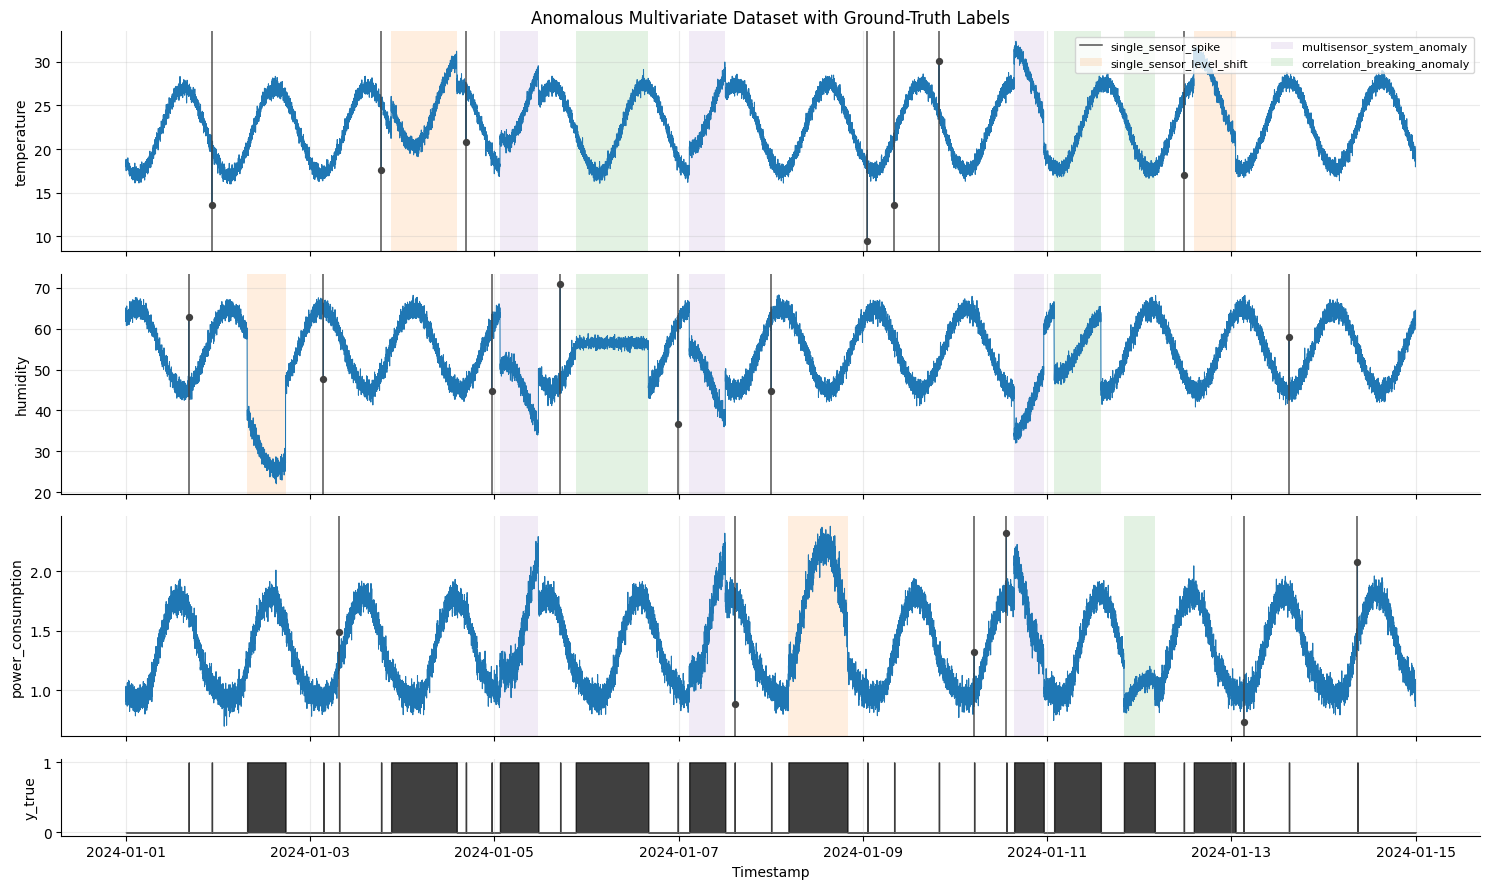

In [4]:
# Create a copy of the normal dataset.
# All anomalies will be injected into this copy, while df_normal remains unchanged
# and can still be used as the clean reference signal.
df_anom = df_normal.copy()

# Ground-truth label array.
# 0 = normal timestamp
# 1 = anomalous timestamp
y_true = np.zeros(N_SAMPLES, dtype=int)

# Boolean array used only during anomaly injection.
# It keeps track of timestamps that are already occupied by an anomaly,
# so that new anomalies are not placed on top of existing ones.
blocked_intervals = np.zeros(N_SAMPLES, dtype=bool)

# List used to store metadata for each injected anomaly event.
# It will later be converted into a dataframe.
anomaly_records: list[dict] = []


# Reset anomaly random generator every time this cell is executed.
# This makes the injected anomaly positions and magnitudes reproducible.
rng_anom = np.random.default_rng(RANDOM_SEED + 1)

# Inject short one-point anomalies that affect only one sensor at a time.
# These simulate isolated sensor faults or sudden measurement errors.
inject_single_sensor_spikes(
    df_anom,
    y_true,
    blocked_intervals,
    anomaly_records,
    rng_anom,
)


# Inject correlation-breaking anomalies early.
# These are among the most important anomalies for this experiment because
# they test whether MSTUMP can detect abnormal relationships between sensors.
# They are also relatively long, so placing them early makes it easier to find
# suitable non-overlapping intervals.
inject_correlation_breaking_anomalies(
    df_anom,
    df_normal,
    y_true,
    blocked_intervals,
    anomaly_records,
    rng_anom,
)


# Inject sustained single-sensor level shifts.
# These affect only one variable for several hours.
inject_single_sensor_level_shifts(
    df_anom,
    y_true,
    blocked_intervals,
    anomaly_records,
    rng_anom,
)


# Inject system-level anomalies.
# These affect all three sensors together and simulate broader abnormal
# operating conditions.
inject_multisensor_system_anomalies(
    df_anom,
    y_true,
    blocked_intervals,
    anomaly_records,
    rng_anom,
)


# Apply final physical limits after all anomaly modifications.
# This prevents impossible values such as negative humidity or negative power.
df_anom["humidity"] = df_anom["humidity"].clip(0.0, 100.0)
df_anom["power_consumption"] = df_anom["power_consumption"].clip(lower=0.05)


anomaly_metadata = (
    pd.DataFrame(anomaly_records)
    .sort_values("start_idx")
    .reset_index(drop=True)
)

y_true_series = pd.Series(y_true, index=datetime_index, name="is_anomaly")

print(f"Injected anomaly events: {len(anomaly_metadata)}")
print(f"Anomalous points: {int(y_true.sum()):,} / {len(y_true):,}")

display(anomaly_metadata)
display(anomaly_metadata["type"].value_counts().rename("event_count"))


ANOMALY_COLORS = {
    "single_sensor_spike": "0.25",
    "single_sensor_level_shift": "tab:orange",
    "multisensor_system_anomaly": "tab:purple",
    "correlation_breaking_anomaly": "tab:green",
}


def get_affected_sensors(row) -> list[str]:
    """
    Return the list of sensors affected by a specific anomaly event.

    This is used only for plotting, so that each anomaly is highlighted only
    on the sensor panels where it is relevant.
    """

    affected = row.affected_sensor_or_relationship

    if affected in SENSOR_COLUMNS:
        return [affected]

    if affected == "temperature_humidity_power":
        return SENSOR_COLUMNS

    if affected == "humidity_temperature_relationship":
        return ["temperature", "humidity"]

    if affected == "power_temperature_load_relationship":
        return ["temperature", "power_consumption"]

    return SENSOR_COLUMNS


def add_anomaly_highlights_for_sensor(
    ax: plt.Axes,
    df: pd.DataFrame,
    metadata: pd.DataFrame,
    sensor: str,
    alpha: float = 0.12,
    add_labels: bool = False,
) -> None:
    """
    Add anomaly regions to one sensor subplot.
    """

    seen_labels: set[str] = set()

    for row in metadata.itertuples(index=False):
        affected_sensors = get_affected_sensors(row)
        if sensor not in affected_sensors:
            continue

        color = ANOMALY_COLORS.get(row.type, "0.5")
        start_idx = int(row.start_idx)
        end_idx = int(row.end_idx)
        start_time = datetime_index[start_idx]

        if end_idx + 1 < len(datetime_index):
            end_time = datetime_index[end_idx + 1]
        else:
            end_time = datetime_index[end_idx] + pd.Timedelta(minutes=1)

        label = None
        if add_labels and row.type not in seen_labels:
            label = row.type
            seen_labels.add(row.type)

        if start_idx == end_idx:
            ax.axvline(start_time, color=color, alpha=0.9, linewidth=1.1, label=label)
            ax.scatter(
                df.index[start_idx],
                df.iloc[start_idx][sensor],
                color=color,
                s=18,
                zorder=3,
            )
        else:
            ax.axvspan(
                start_time,
                end_time,
                color=color,
                alpha=alpha,
                linewidth=0,
                label=label,
            )


def plot_anomalous_dataset_with_labels(
    df: pd.DataFrame,
    y: np.ndarray,
    metadata: pd.DataFrame,
) -> plt.Figure:
    """
    Plot the anomalous dataset and the point-level ground-truth labels.
    """

    fig, axes = plt.subplots(
        len(SENSOR_COLUMNS) + 1,
        1,
        figsize=(15, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [1] * len(SENSOR_COLUMNS) + [0.35]},
    )

    for ax, sensor in zip(axes[:-1], SENSOR_COLUMNS):
        ax.plot(df.index, df[sensor], linewidth=0.75, color="tab:blue")
        add_anomaly_highlights_for_sensor(
            ax,
            df,
            metadata,
            sensor=sensor,
            alpha=0.13,
            add_labels=(sensor == SENSOR_COLUMNS[0]),
        )
        ax.set_ylabel(sensor)

    axes[-1].fill_between(df.index, y, step="pre", color="black", alpha=0.75)
    axes[-1].set_yticks([0, 1])
    axes[-1].set_ylabel("y_true")
    axes[-1].set_xlabel("Timestamp")
    axes[0].set_title("Anomalous Multivariate Dataset with Ground-Truth Labels")
    axes[0].legend(loc="upper right", ncol=2, fontsize=8)

    fig.tight_layout()
    return fig


fig = plot_anomalous_dataset_with_labels(df_anom, y_true, anomaly_metadata)
save_figure(fig, "anomalous_multivariate_dataset_with_labels")
plt.show()


**Summary**

The anomalous dataset plot is a quick visual check after injection. Each sensor is shown separately, and the highlighted regions indicate where the known anomalies were placed.

The spike events appear as narrow vertical markers, while level shifts and longer system events appear as shaded intervals. Correlation-breaking anomalies are shown on the sensors involved in the abnormal relationship, for example temperature and humidity or temperature and power consumption.

The final panel shows `y_true`. This label is defined for the whole multivariate system, not for a single sensor. A value of `1` means that at least one injected anomaly is active at that timestamp.

## 4. Data Preparation and Score Alignment

The Matrix Profile input is kept in the original sensor units. I do not globally standardize the full sensor columns before running STUMP or MSTUMP. This follows the usual Matrix Profile setup, because STUMPY compares subsequences using z-normalized distances internally.

Missing values are handled separately from ordinary preprocessing. If a timestamp contains a missing sensor reading, it is first treated as anomalous. In an IoT setting, a missing value may represent a sensor fault, a communication problem, or another data-quality issue. For that reason, missing timestamps are added to `y_true` and recorded in the anomaly metadata before any filling is done.

After that labeling step, missing values are filled only so that STUMPY receives finite numeric arrays. This filling is a technical requirement for running the algorithms, not a decision to ignore the missing data.

A second practical issue is score alignment. STUMP and MSTUMP return one score per subsequence, while the ground-truth labels are point-level labels. The helper function below expands subsequence scores back to timestamp-level scores by assigning each subsequence score to the interval it covers.

In [5]:
# -------------------------------------------------------------------------
# Prepare raw numeric data for Matrix Profile
# -------------------------------------------------------------------------

# STUMP and MSTUMP use z-normalized subsequence distances internally.
# Therefore, the Matrix Profile input is kept in the original sensor units.
df_raw_mp = df_anom[SENSOR_COLUMNS].apply(pd.to_numeric, errors="coerce")


def contiguous_true_intervals(mask: np.ndarray) -> list[tuple[int, int]]:
    """
    Convert a boolean mask into contiguous [start, end_exclusive) intervals.
    """

    true_positions = np.flatnonzero(mask)
    if len(true_positions) == 0:
        return []

    split_points = np.where(np.diff(true_positions) > 1)[0] + 1
    groups = np.split(true_positions, split_points)
    return [(int(group[0]), int(group[-1]) + 1) for group in groups]


# -------------------------------------------------------------------------
# Missing-value policy
# -------------------------------------------------------------------------

# Missing values are treated as anomaly evidence before any filling occurs.
# This is important for IoT data, where missing readings can mean sensor
# failure, communication loss, or another data-quality issue.
missing_by_sensor = df_raw_mp.isna()
missing_point_mask = missing_by_sensor.any(axis=1).to_numpy()
missing_counts_by_sensor = (
    missing_by_sensor
    .sum()
    .rename("missing_count")
    .to_frame()
)

# Record missing-value intervals as anomalies in the metadata, and mark them in y_true. 
missing_records: list[dict] = []
for event_number, (start_idx, end_idx_exclusive) in enumerate(
    contiguous_true_intervals(missing_point_mask),
    start=1,
):
    affected_sensors = [
        sensor
        for sensor in SENSOR_COLUMNS
        if missing_by_sensor.iloc[start_idx:end_idx_exclusive][sensor].any()
    ]

    # Mark missing timestamps as anomalous before any values are filled.
    y_true[start_idx:end_idx_exclusive] = 1

    end_idx_inclusive = end_idx_exclusive - 1
    missing_records.append(
        {
            "anomaly_id": f"MV_{event_number:02d}",
            "type": "missing_value_anomaly",
            "affected_sensor_or_relationship": "_".join(affected_sensors),
            "start_time": datetime_index[start_idx],
            "end_time": datetime_index[end_idx_inclusive],
            "start_idx": start_idx,
            "end_idx": end_idx_inclusive,
            "duration_minutes": end_idx_exclusive - start_idx,
            "description": (
                "Missing sensor values were treated as anomalous before "
                "technical filling for Matrix Profile computation."
            ),
        }
    )

if missing_records:
    missing_metadata = pd.DataFrame(missing_records)
    anomaly_metadata = (
        pd.concat([anomaly_metadata, missing_metadata], ignore_index=True)
        .sort_values("start_idx")
        .reset_index(drop=True)
    )
    print(f"Recorded {len(missing_metadata)} missing-value anomaly interval(s).")
else:
    missing_metadata = pd.DataFrame(columns=anomaly_metadata.columns)
    print("No missing values were found in the anomalous dataset.")

# Refresh the label series after possible missing-value labeling.
y_true_series = pd.Series(y_true, index=datetime_index, name="is_anomaly")

display(missing_counts_by_sensor)


# -------------------------------------------------------------------------
# Technical filling for STUMPY
# -------------------------------------------------------------------------

# STUMPY requires finite numeric arrays. Missing values have already been
# recorded as anomalies above, so interpolation here is only a technical step
# that makes the Matrix Profile computation possible.
df_mp_input = (
    df_raw_mp
    .interpolate(method="time", limit_direction="both")
    .ffill()
    .bfill()
)

# If an entire column were missing, interpolation/forward/backward filling could
# still leave NaN values. Fill any remaining values with the available column
# median, and finally with 0 only as a last-resort technical fallback.
if df_mp_input.isna().any().any():
    column_medians = df_raw_mp.median(axis=0)
    df_mp_input = df_mp_input.fillna(column_medians).fillna(0.0)

assert not df_mp_input.isna().any().any(), "Matrix Profile input contains NaN values."
assert np.isfinite(df_mp_input.to_numpy(dtype=np.float64)).all(), (
    "Matrix Profile input contains non-finite values."
)

# This table is intentionally in the original sensor units, not standardized units.
display(df_mp_input.describe().T)


# -------------------------------------------------------------------------
# Helper functions for Matrix Profile scores
# -------------------------------------------------------------------------

def replace_nonfinite_with_max(values: np.ndarray) -> np.ndarray:
    """
    Replace non-finite Matrix Profile values with the maximum finite value.

    Matrix Profile outputs may occasionally contain inf or NaN values,
    for example near invalid subsequences. Since high Matrix Profile values
    are treated as more anomalous, replacing non-finite values with the
    maximum finite value is a conservative choice.
    """

    values = np.asarray(values, dtype=float).copy()
    finite = np.isfinite(values)

    if not finite.any():
        raise ValueError("Profile contains no finite values.")

    max_finite = np.max(values[finite])
    values[~finite] = max_finite

    return values


def subsequence_scores_to_point_scores(
    subsequence_scores: np.ndarray,
    m: int,
    n_samples: int,
) -> np.ndarray:
    """
    Convert subsequence-level Matrix Profile scores to point-level scores.

    Matrix Profile returns one score for each subsequence of length m.
    Therefore, for a time series with n samples, the output length is:

        n - m + 1

    However, the ground-truth labels are defined per timestamp. To compare
    the Matrix Profile scores with y_true, each subsequence score is assigned
    to all timestamps covered by that subsequence.

    If several subsequences cover the same timestamp, the maximum score is used.
    This means that a timestamp receives a high anomaly score if it belongs to
    at least one highly unusual subsequence.
    """

    subsequence_scores = replace_nonfinite_with_max(subsequence_scores)

    expected_length = n_samples - m + 1
    if len(subsequence_scores) != expected_length:
        raise ValueError(
            f"Expected {expected_length} subsequence scores, got {len(subsequence_scores)}."
        )

    point_scores = np.full(n_samples, -np.inf, dtype=float)

    for start_idx, score in enumerate(subsequence_scores):
        end_idx = start_idx + m
        point_scores[start_idx:end_idx] = np.maximum(
            point_scores[start_idx:end_idx],
            score,
        )

    min_score = float(np.min(subsequence_scores))
    point_scores[~np.isfinite(point_scores)] = min_score

    return point_scores


def minmax_normalize(values: np.ndarray) -> np.ndarray:
    """
    Normalize an array to the range [0, 1].

    This is used to make anomaly scores from different methods easier to
    compare in plots and aggregated baselines.
    """

    values = np.asarray(values, dtype=float).copy()
    finite = np.isfinite(values)

    if not finite.any():
        return np.zeros_like(values, dtype=float)

    median_finite = float(np.median(values[finite]))
    values[~finite] = median_finite

    min_value = float(np.min(values))
    max_value = float(np.max(values))

    if np.isclose(max_value, min_value):
        return np.zeros_like(values, dtype=float)

    return (values - min_value) / (max_value - min_value)


No missing values were found in the anomalous dataset.


,missing_count
temperature,0
humidity,0
power_consumption,0


,count,mean,std,min,25%,50%,75%,max
temperature,20160.0,22.924064,3.697030,9.436727,19.545360,23.060344,26.291843,32.349035
humidity,20160.0,53.361486,8.393972,22.028561,47.221055,53.861975,60.545590,70.999170
power_consumption,20160.0,1.361506,0.343226,0.699596,1.046454,1.307136,1.677026,2.377705


**Summary**

At this point the Matrix Profile input is numeric, finite, and still expressed in the original units of each sensor. No global z-score transformation has been applied to the columns.

The missing-value table shows whether any missing readings were found. If missing values exist, the notebook records them as `missing_value_anomaly` intervals before filling them for computation. In the generated synthetic dataset there may be no missing readings, but the handling is included so the method is explicit.

The remaining helper functions prepare the anomaly scores for evaluation. Since Matrix Profile scores are subsequence-based, they are expanded to the timestamp level and then normalized to `[0, 1]` only for plotting, aggregation, and metric comparison.

## 5. Univariate Matrix Profile Baselines

The first detection step is the univariate baseline. Each sensor is processed independently with STUMP using the same subsequence length, `m = 720`.

These baselines are needed because they show what can be detected from each channel on its own. If a single-sensor method already performs well, then the multivariate method must be judged against that reference rather than in isolation.

For each sensor, the Matrix Profile distance is used as the anomaly score. Higher values correspond to subsequences that are less similar to the rest of the signal. Since the output is subsequence-based, the scores are expanded back to point-level timestamps before evaluation.

Two simple aggregated baselines are also created:

| Score | Meaning |
|---|---|
| `score_uni_max` | Takes the highest univariate score at each timestamp |
| `score_uni_mean` | Takes the average univariate score at each timestamp |

The maximum score is useful for isolated sensor faults. The mean score is more useful when several sensors become moderately unusual at the same time.

In [6]:
# -------------------------------------------------------------------------
# Run univariate Matrix Profile baselines
# -------------------------------------------------------------------------

# Use the main Matrix Profile window size.
# With 1-minute sampling, m = 720 corresponds to a 12-hour subsequence.
m = WINDOW_SIZE_MAIN

# DataFrame that will store the point-level anomaly scores for each sensor.
univariate_score_df = pd.DataFrame(index=datetime_index)

# Dictionary that stores the original subsequence-level Matrix Profiles.
# These are kept mainly for inspection or later analysis.
univariate_subsequence_profiles: dict[str, np.ndarray] = {}

# Measure runtime for the univariate baseline computation.
start_time = time.perf_counter()


# Run one independent Matrix Profile per sensor.
# This baseline answers the question:
# "Can the anomaly be detected from this sensor alone?"
for sensor in SENSOR_COLUMNS:

    # Use the raw numeric sensor signal. STUMP internally compares
    # z-normalized subsequences, so no global column standardization is applied.
    sensor_values = df_mp_input[sensor].to_numpy(dtype=np.float64)

    # Compute the univariate Matrix Profile using STUMP.
    # The output has one row per subsequence.
    # Column 0 contains the Matrix Profile distance.
    # Larger distances correspond to more unusual subsequences.
    mp = stumpy.stump(sensor_values, m=m)

    # Extract the Matrix Profile distance values.
    subsequence_profile = np.asarray(mp[:, 0], dtype=float)

    # Convert the subsequence-level profile into a point-level anomaly score.
    # This is needed because y_true is defined per timestamp, not per subsequence.
    point_scores = subsequence_scores_to_point_scores(
        subsequence_profile,
        m=m,
        n_samples=N_SAMPLES,
    )

    # Normalize the point-level score to [0, 1].
    # This does not affect the ranking of anomalies, but it makes scores from
    # different sensors comparable and allows fair max/mean aggregation.
    score_column = f"score_mp_{sensor}"
    univariate_score_df[score_column] = minmax_normalize(point_scores)

    # Store the original subsequence profile as well.
    univariate_subsequence_profiles[sensor] = subsequence_profile

    print(
        f"Finished STUMP for {sensor}: "
        f"{len(subsequence_profile):,} subsequence scores"
    )


# Print total runtime.
elapsed = time.perf_counter() - start_time
print(f"Univariate STUMP baselines completed in {elapsed:.2f} seconds.")


# -------------------------------------------------------------------------
# Aggregate univariate scores across sensors
# -------------------------------------------------------------------------

# Select all individual sensor score columns.
per_sensor_score_columns = [f"score_mp_{sensor}" for sensor in SENSOR_COLUMNS]

# Max aggregation:
# A timestamp receives a high score if at least one sensor is highly unusual.
univariate_score_df["score_uni_max"] = (
    univariate_score_df[per_sensor_score_columns].max(axis=1)
)

# Mean aggregation:
# A timestamp receives a high score when several sensors are moderately unusual.
univariate_score_df["score_uni_mean"] = (
    univariate_score_df[per_sensor_score_columns].mean(axis=1)
)


# Display the first rows of the generated score table.
display(univariate_score_df.head())


Finished STUMP for temperature: 19,441 subsequence scores
Finished STUMP for humidity: 19,441 subsequence scores
Finished STUMP for power_consumption: 19,441 subsequence scores
Univariate STUMP baselines completed in 19.52 seconds.


,score_mp_temperature,score_mp_humidity,score_mp_power_consumption,score_uni_max,score_uni_mean
2024-01-01 00:00:00,0.0,0.0,0.017756,0.017756,0.005919
2024-01-01 00:01:00,0.0,0.0,0.017756,0.017756,0.005919
2024-01-01 00:02:00,0.0,0.0,0.017756,0.017756,0.005919
2024-01-01 00:03:00,0.0,0.0,0.017756,0.017756,0.005919
2024-01-01 00:04:00,0.0,0.0,0.017756,0.017756,0.005919


Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\sensor_values_with_univariate_mp_scores.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\sensor_values_with_univariate_mp_scores.pdf


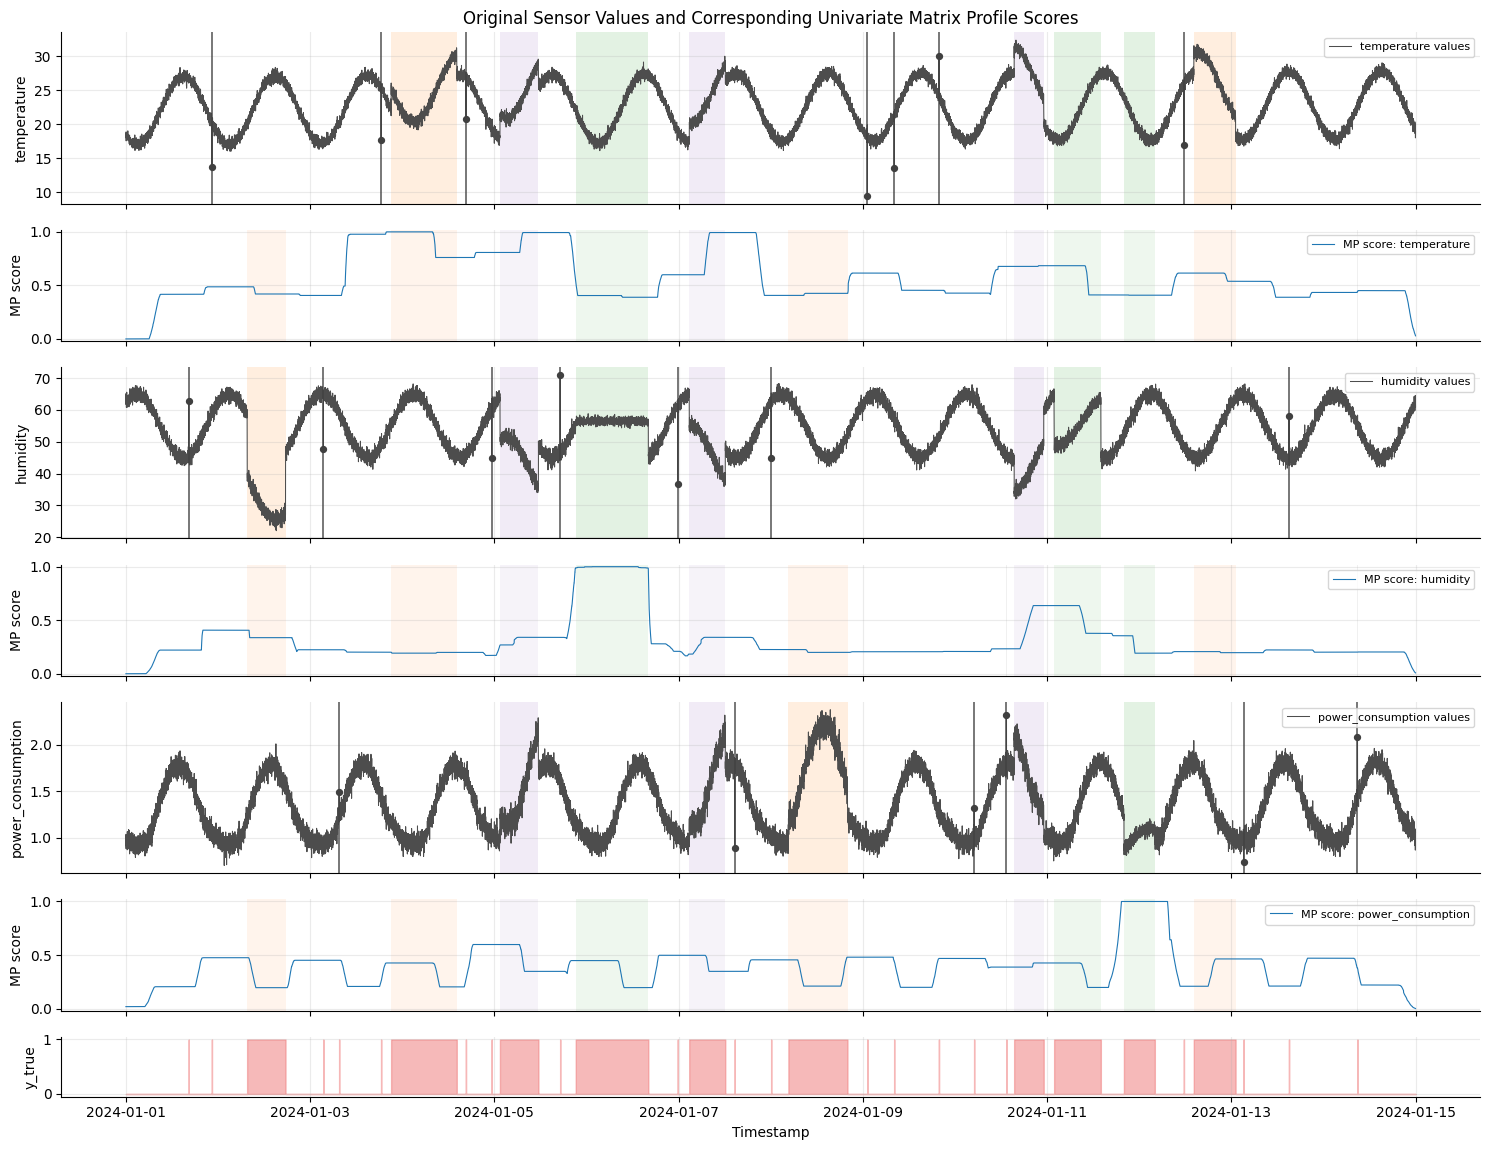

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\aggregated_univariate_mp_scores.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\aggregated_univariate_mp_scores.pdf


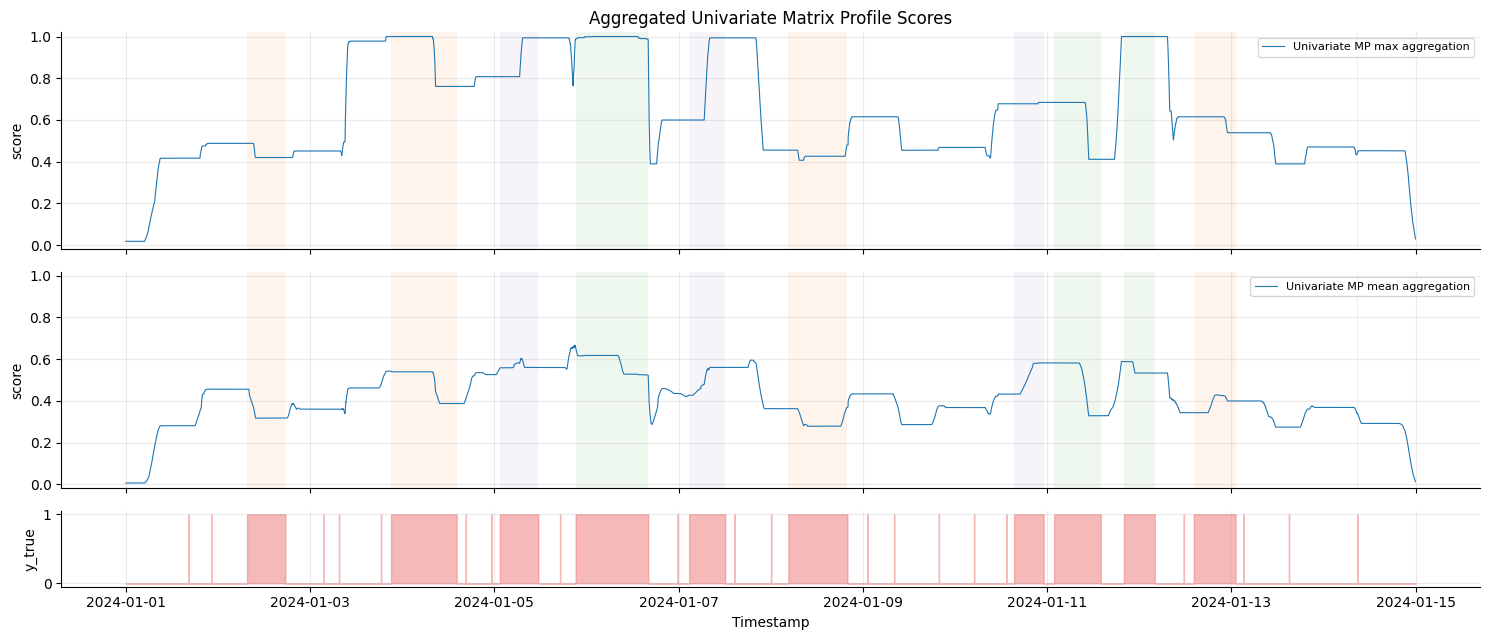

In [7]:
# -------------------------------------------------------------------------
# Plot helper: show all anomaly intervals in score plots
# -------------------------------------------------------------------------

def add_all_anomaly_spans(
    ax: plt.Axes,
    metadata: pd.DataFrame,
    alpha: float = 0.10,
) -> None:
    """
    Add all ground-truth anomaly intervals as shaded regions.

    In score plots, all anomaly intervals are shown on every panel because
    each score is being compared against the full multivariate ground truth.
    """

    for row in metadata.itertuples(index=False):
        color = ANOMALY_COLORS.get(row.type, "0.5")

        start_idx = int(row.start_idx)
        end_idx = int(row.end_idx)

        start_time = datetime_index[start_idx]

        if end_idx + 1 < len(datetime_index):
            end_time = datetime_index[end_idx + 1]
        else:
            end_time = datetime_index[end_idx] + pd.Timedelta(minutes=1)

        ax.axvspan(
            start_time,
            end_time,
            color=color,
            alpha=alpha,
            linewidth=0,
        )


# -------------------------------------------------------------------------
# Plot original sensor values and corresponding univariate MP scores
# -------------------------------------------------------------------------

def plot_sensor_values_with_mp_scores(
    df_values: pd.DataFrame,
    score_df: pd.DataFrame,
    y: np.ndarray,
    metadata: pd.DataFrame,
) -> plt.Figure:
    """
    Plot each original sensor signal together with its corresponding
    univariate Matrix Profile anomaly score.

    For each sensor:
    - The first panel shows the original anomalous sensor values.
    - The second panel shows the normalized Matrix Profile score.
    """

    n_sensors = len(SENSOR_COLUMNS)

    fig, axes = plt.subplots(
        n_sensors * 2 + 1,
        1,
        figsize=(15, 3.2 * n_sensors + 2),
        sharex=True,
        gridspec_kw={
            "height_ratios": sum(([1.0, 0.65] for _ in SENSOR_COLUMNS), []) + [0.35]
        },
    )

    for i, sensor in enumerate(SENSOR_COLUMNS):
        signal_ax = axes[2 * i]
        score_ax = axes[2 * i + 1]

        score_column = f"score_mp_{sensor}"

        # Plot original sensor values in original units.
        signal_ax.plot(
            df_values.index,
            df_values[sensor],
            linewidth=0.75,
            color="0.30",
            label=f"{sensor} values",
        )

        # Highlight only the anomalies relevant to this sensor.
        add_anomaly_highlights_for_sensor(
            ax=signal_ax,
            df=df_values,
            metadata=metadata,
            sensor=sensor,
            alpha=0.13,
            add_labels=False,
        )

        signal_ax.set_ylabel(sensor)
        signal_ax.legend(loc="upper right", fontsize=8)

        # Plot the normalized univariate Matrix Profile score.
        score_ax.plot(
            score_df.index,
            score_df[score_column],
            linewidth=0.8,
            color="tab:blue",
            label=f"MP score: {sensor}",
        )

        # In score plots, show all anomaly intervals.
        add_all_anomaly_spans(
            score_ax,
            metadata,
            alpha=0.08,
        )

        score_ax.set_ylabel("MP score")
        score_ax.set_ylim(-0.02, 1.02)
        score_ax.legend(loc="upper right", fontsize=8)

    # Final panel: ground-truth anomaly label.
    axes[-1].fill_between(
        df_values.index,
        y,
        step="pre",
        color="lightcoral",
        alpha=0.55,
    )

    axes[-1].set_yticks([0, 1])
    axes[-1].set_ylabel("y_true")
    axes[-1].set_xlabel("Timestamp")

    axes[0].set_title(
        "Original Sensor Values and Corresponding Univariate Matrix Profile Scores"
    )

    fig.tight_layout()
    return fig


fig = plot_sensor_values_with_mp_scores(
    df_values=df_anom,
    score_df=univariate_score_df,
    y=y_true,
    metadata=anomaly_metadata,
)

save_figure(fig, "sensor_values_with_univariate_mp_scores")
plt.show()


# -------------------------------------------------------------------------
# Plot aggregated univariate scores
# -------------------------------------------------------------------------

def plot_aggregated_univariate_scores(
    score_df: pd.DataFrame,
    y: np.ndarray,
    metadata: pd.DataFrame,
) -> plt.Figure:
    """
    Plot the two aggregated univariate Matrix Profile scores:
    - score_uni_max
    - score_uni_mean

    These are simple multichannel baselines created from the independent
    univariate Matrix Profile scores.
    """

    plot_columns = [
        ("Univariate MP max aggregation", "score_uni_max"),
        ("Univariate MP mean aggregation", "score_uni_mean"),
    ]

    fig, axes = plt.subplots(
        len(plot_columns) + 1,
        1,
        figsize=(15, 6.5),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 0.35]},
    )

    for ax, (label, column) in zip(axes[:-1], plot_columns):
        ax.plot(
            score_df.index,
            score_df[column],
            linewidth=0.8,
            color="tab:blue",
            label=label,
        )

        add_all_anomaly_spans(
            ax,
            metadata,
            alpha=0.08,
        )

        ax.set_ylabel("score")
        ax.set_ylim(-0.02, 1.02)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].fill_between(
        score_df.index,
        y,
        step="pre",
        color="lightcoral",
        alpha=0.55,
    )

    axes[-1].set_yticks([0, 1])
    axes[-1].set_ylabel("y_true")
    axes[-1].set_xlabel("Timestamp")

    axes[0].set_title("Aggregated Univariate Matrix Profile Scores")

    fig.tight_layout()
    return fig


fig = plot_aggregated_univariate_scores(
    score_df=univariate_score_df,
    y=y_true,
    metadata=anomaly_metadata,
)

save_figure(fig, "aggregated_univariate_mp_scores")
plt.show()


**Summary of the Univariate Results**

The univariate baselines provide the first reference point for the multivariate experiment. Each Matrix Profile score is computed from one sensor only, while the max and mean scores combine the three independent profiles after they have already been calculated.

With the window size set to \(m = 720\), each score represents the abnormality of a 12-hour subsequence. This makes the scores smoother and more suitable for the longer injected anomalies, such as level shifts, multisensor events, and correlation-breaking intervals.

The plots show that some injected anomalies are followed by clear increases in the Matrix Profile scores. This is especially visible in longer abnormal intervals. However, high scores can also appear outside the labeled anomaly regions. This is expected in a strongly periodic dataset, because a subsequence may be unusual compared with the rest of the signal even if it is not part of a labeled anomaly.

The aggregated max score is useful when at least one sensor becomes clearly unusual. The mean score is smoother and becomes higher when several sensors show moderate changes at the same time. However, both are still based on independent univariate profiles.

The main limitation of the univariate approach is that it cannot directly model relationships between sensors. For example, humidity may remain within a plausible range by itself, but still behave incorrectly relative to temperature. This limitation motivates the use of MSTUMP in the next section, where subsequences are evaluated across multiple sensors jointly.

## 6. Multidimensional Matrix Profile with MSTUMP

MSTUMP is the multidimensional version of the Matrix Profile used in this notebook. STUMPY expects the input array in dimensions-by-time format, so the three sensor columns are transposed before the algorithm is called:

```python
T = df_mp_input[["temperature", "humidity", "power_consumption"]].values.T
```

The output `P` contains one profile for each dimensionality:

- `P[0]`: best 1-dimensional profile
- `P[1]`: best 2-dimensional profile
- `P[2]`: best 3-dimensional profile

As in the univariate case, the input is not globally standardized. MSTUMP uses z-normalized subsequence distances internally, so the raw numeric sensor values are appropriate for the computation.

In [8]:
# MSTUMP expects the multivariate signal in dimensions x time format.
# The input is raw numeric data after missing values have been labeled and
# technically filled for STUMPY.
T = df_mp_input[SENSOR_COLUMNS].to_numpy(dtype=np.float64).T
assert T.shape == (len(SENSOR_COLUMNS), N_SAMPLES)

start_time = time.perf_counter()
P, I = stumpy.mstump(T, m=m)
elapsed = time.perf_counter() - start_time

print(f"MSTUMP input shape: {T.shape}")
print(f"MSTUMP P shape: {P.shape}")
print(f"MSTUMP completed in {elapsed:.2f} seconds.")

mstump_score_df = pd.DataFrame(index=datetime_index)
mstump_subsequence_profiles: dict[str, np.ndarray] = {}

# P[k - 1] is the best k-dimensional Matrix Profile. For example, P[1]
# represents the best 2-dimensional profile discovered across sensor pairs.
for k in range(1, len(SENSOR_COLUMNS) + 1):
    subsequence_profile = np.asarray(P[k - 1], dtype=float)

    # Align the subsequence score to point labels using the same method as the
    # univariate baseline, so evaluation is comparable.
    point_scores = subsequence_scores_to_point_scores(
        subsequence_profile,
        m=m,
        n_samples=N_SAMPLES,
    )

    column = f"score_mstump_{k}d"
    mstump_score_df[column] = minmax_normalize(point_scores)
    mstump_subsequence_profiles[column] = subsequence_profile

all_score_df = pd.concat([univariate_score_df, mstump_score_df], axis=1)
display(all_score_df.head())


MSTUMP input shape: (3, 20160)
MSTUMP P shape: (3, 19441)
MSTUMP completed in 31.16 seconds.


,score_mp_temperature,score_mp_humidity,score_mp_power_consumption,score_uni_max,score_uni_mean,score_mstump_1d,score_mstump_2d,score_mstump_3d
2024-01-01 00:00:00,0.0,0.0,0.017756,0.017756,0.005919,0.0,0.0,0.0
2024-01-01 00:01:00,0.0,0.0,0.017756,0.017756,0.005919,0.0,0.0,0.0
2024-01-01 00:02:00,0.0,0.0,0.017756,0.017756,0.005919,0.0,0.0,0.0
2024-01-01 00:03:00,0.0,0.0,0.017756,0.017756,0.005919,0.0,0.0,0.0
2024-01-01 00:04:00,0.0,0.0,0.017756,0.017756,0.005919,0.0,0.0,0.0


Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\mstump_score_profiles.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\mstump_score_profiles.pdf


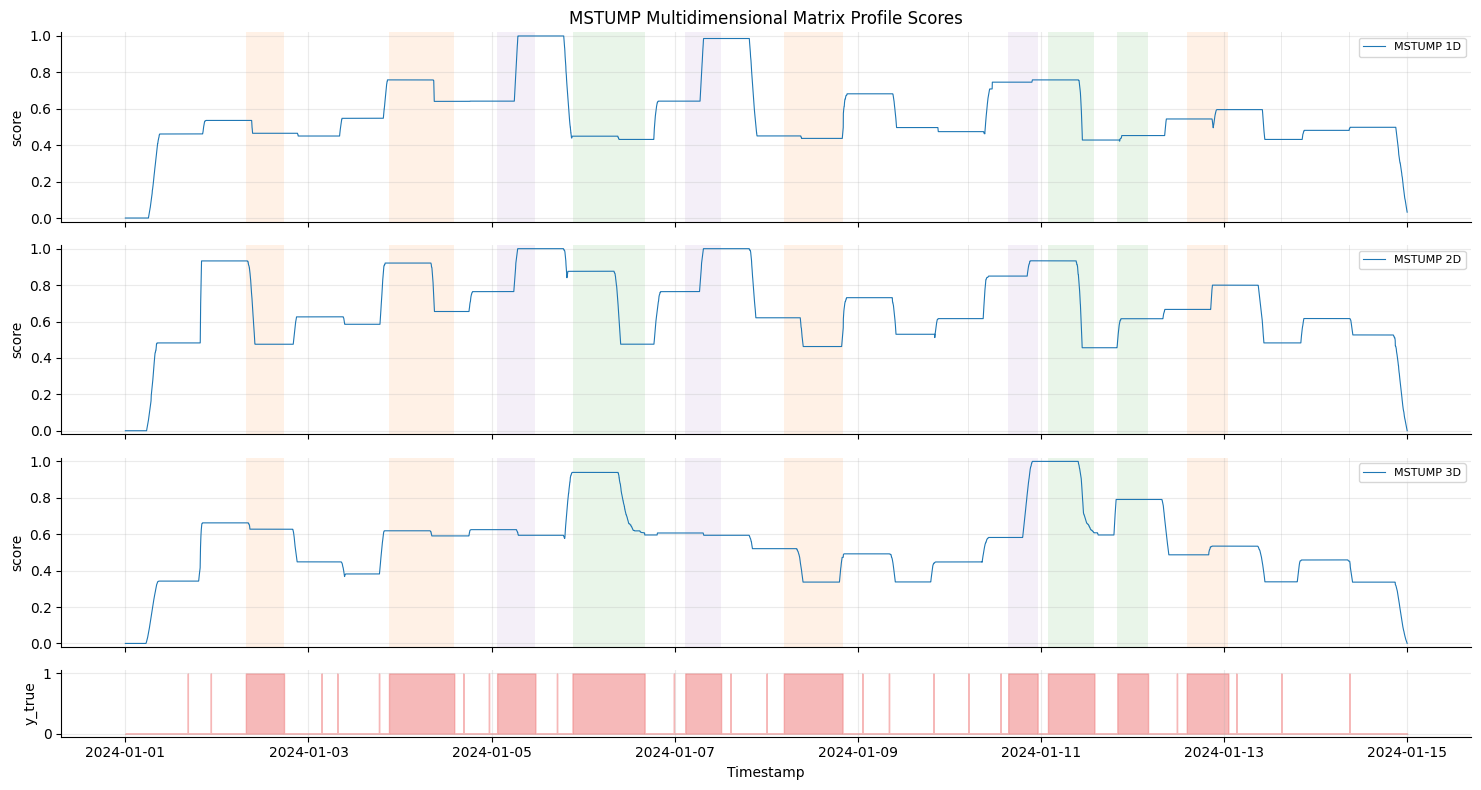

In [9]:
# -------------------------------------------------------------------------
# Plot MSTUMP multidimensional Matrix Profile scores
# -------------------------------------------------------------------------

def plot_mstump_score_profiles(
    score_df: pd.DataFrame,
    y: np.ndarray,
    metadata: pd.DataFrame,
) -> plt.Figure:
    """
    Plot the MSTUMP anomaly scores for each dimensionality level.

    For a 3-sensor dataset:
    - score_mstump_1d is the best 1-dimensional profile
    - score_mstump_2d is the best 2-dimensional profile
    - score_mstump_3d is the full 3-dimensional profile

    The final panel shows the point-level ground-truth anomaly label.
    """

    plot_columns = [
        (f"MSTUMP {k}D", f"score_mstump_{k}d")
        for k in range(1, len(SENSOR_COLUMNS) + 1)
    ]

    fig, axes = plt.subplots(
        len(plot_columns) + 1,
        1,
        figsize=(15, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [1] * len(plot_columns) + [0.35]},
    )

    for ax, (label, column) in zip(axes[:-1], plot_columns):

        # Plot the normalized MSTUMP score.
        ax.plot(
            score_df.index,
            score_df[column],
            linewidth=0.8,
            color="tab:blue",
            label=label,
        )

        # In score plots, all ground-truth anomaly intervals are shown.
        # This allows visual comparison between the anomaly score and y_true.
        add_all_anomaly_spans(
            ax,
            metadata,
            alpha=0.10,
        )

        ax.set_ylabel("score")
        ax.set_ylim(-0.02, 1.02)
        ax.legend(loc="upper right", fontsize=8)

    # Final panel: ground-truth anomaly label.
    axes[-1].fill_between(
        score_df.index,
        y,
        step="pre",
        color="lightcoral",
        alpha=0.55,
    )

    axes[-1].set_yticks([0, 1])
    axes[-1].set_ylabel("y_true")
    axes[-1].set_xlabel("Timestamp")

    axes[0].set_title("MSTUMP Multidimensional Matrix Profile Scores")

    fig.tight_layout()
    return fig


fig = plot_mstump_score_profiles(
    mstump_score_df,
    y_true,
    anomaly_metadata,
)

save_figure(fig, "mstump_score_profiles")
plt.show()

**Plot interpretation**

The MSTUMP plot shows the multidimensional Matrix Profile scores for the 1D, 2D, and 3D profiles. With \(m = 720\), each score represents the abnormality of a 12-hour subsequence. The final panel shows the ground-truth label, where a value of 1 means that an anomaly is active at that timestamp.

The 1D profile is based on the best single dimension selected by MSTUMP. The 2D profile uses the best pair of sensors, while the 3D profile uses temperature, humidity, and power consumption together. Therefore, the 2D and 3D profiles are the most relevant ones for checking whether the method captures multivariate behaviour.

The plot shows that several longer anomaly intervals lead to higher MSTUMP scores. This is especially visible around some multisensor and correlation-breaking anomalies. This is expected, because these anomalies affect the joint behaviour of the system rather than only one isolated sensor.

However, the scores are not high only inside the labeled anomaly regions. Some high-score regions also appear during normal periods. This can happen because the dataset has a strong daily pattern, and Matrix Profile detects subsequences that are unusual compared with the rest of the series, even if they are not labeled as injected anomalies.

Overall, the plot suggests that MSTUMP reacts to some of the injected multivariate events, but it does not perfectly separate all anomalous and normal regions visually. For this reason, the final interpretation should rely on the quantitative metrics as well as the visual inspection.

## 7. Evaluation Against Ground Truth

The evaluation uses both ranking-based metrics and threshold-based metrics.

Ranking metrics are useful because they do not require choosing one fixed cutoff. Here I use ROC AUC and Average Precision, also referred to as PR AUC.

I also test percentile thresholds at p95, p97, and p99. This gives a more operational view of the results: a timestamp is flagged as anomalous if its score is among the highest values for that method.

In all cases, higher Matrix Profile values are treated as stronger anomaly evidence.

In [10]:
METHOD_SCORE_COLUMNS = {
    "MP_temperature": "score_mp_temperature",
    "MP_humidity": "score_mp_humidity",
    "MP_power_consumption": "score_mp_power_consumption",
    "MP_univariate_max": "score_uni_max",
    "MP_univariate_mean": "score_uni_mean",
    "MSTUMP_1D": "score_mstump_1d",
    "MSTUMP_2D": "score_mstump_2d",
    "MSTUMP_3D": "score_mstump_3d",
}


def evaluate_threshold_free(
    y_true: np.ndarray,
    score_df: pd.DataFrame,
    method_score_columns: dict[str, str],
) -> pd.DataFrame:
    rows = []
    for method, column in method_score_columns.items():
        scores = score_df[column].to_numpy(dtype=float)
        rows.append(
            {
                "method": method,
                "roc_auc": roc_auc_score(y_true, scores),
                "average_precision_pr_auc": average_precision_score(y_true, scores),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["average_precision_pr_auc", "roc_auc"],
        ascending=False,
    )


def evaluate_percentile_thresholds(
    y_true: np.ndarray,
    score_df: pd.DataFrame,
    method_score_columns: dict[str, str],
    percentiles: list[int],
) -> pd.DataFrame:
    rows = []
    for method, column in method_score_columns.items():
        scores = minmax_normalize(score_df[column].to_numpy())
        for percentile in percentiles:
            threshold = np.percentile(scores, percentile)
            y_pred = (scores >= threshold).astype(int)

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1],
            ).ravel()

            rows.append(
                {
                    "method": method,
                    "percentile": percentile,
                    "threshold": threshold,
                    "precision": precision_score(y_true, y_pred, zero_division=0),
                    "recall": recall_score(y_true, y_pred, zero_division=0),
                    "f1": f1_score(y_true, y_pred, zero_division=0),
                    "tp": tp,
                    "fp": fp,
                    "tn": tn,
                    "fn": fn,
                }
            )
    return pd.DataFrame(rows).sort_values(
        ["percentile", "f1", "precision"],
        ascending=[True, False, False],
    )


results_auc = evaluate_threshold_free(y_true, all_score_df, METHOD_SCORE_COLUMNS)
results_thresholds = evaluate_percentile_thresholds(
    y_true,
    all_score_df,
    METHOD_SCORE_COLUMNS,
    percentiles=[95, 97, 99],
)

display(results_auc)
display(results_thresholds)


,method,roc_auc,average_precision_pr_auc
7,MSTUMP_3D,0.769515,0.651484
3,MP_univariate_max,0.701986,0.615421
1,MP_humidity,0.623188,0.599090
4,MP_univariate_mean,0.687070,0.587902
0,MP_temperature,0.545994,0.458082
6,MSTUMP_2D,0.599373,0.455089
5,MSTUMP_1D,0.537530,0.433768
2,MP_power_consumption,0.454411,0.371063


,method,percentile,threshold,precision,recall,f1,tp,fp,tn,fn
9,MP_univariate_max,95,1.000000,0.856944,0.257262,0.395724,1851,309,12656,5344
21,MSTUMP_3D,95,0.939456,0.886394,0.186518,0.308187,1342,172,12793,5853
3,MP_humidity,95,0.990160,1.000000,0.149687,0.260397,1077,0,12965,6118
0,MP_temperature,95,0.993540,0.524424,0.158165,0.243033,1138,1032,11933,6057
12,MP_univariate_mean,95,0.881870,0.777451,0.110215,0.193061,793,227,12738,6402
6,MP_power_consumption,95,0.598952,0.502231,0.109521,0.179827,788,781,12184,6407
18,MSTUMP_2D,95,1.000000,0.388889,0.077832,0.129705,560,880,12085,6635
15,MSTUMP_1D,95,0.986062,0.383817,0.077137,0.128457,555,891,12074,6640
10,MP_univariate_max,97,1.000000,0.856944,0.257262,0.395724,1851,309,12656,5344
4,MP_humidity,97,1.000000,1.000000,0.100069,0.181933,720,0,12965,6475


## 8. Per-Anomaly-Type Detection Coverage

Point-level metrics are helpful, but they do not always tell the full story for interval anomalies. A method may detect part of a long event without flagging every timestamp inside it.

For that reason, this section also uses an event-level view. An anomaly interval is counted as detected if at least one predicted anomalous timestamp falls inside the interval. The results are then grouped by anomaly type, which makes it easier to see which kinds of events each method handles better.

In [11]:
ANOMALY_TYPE_THRESHOLD_PERCENTILE = 97
SELECTED_METHODS_FOR_COVERAGE = {
    "MP_univariate_max": "score_uni_max",
    "MSTUMP_2D": "score_mstump_2d",
    "MSTUMP_3D": "score_mstump_3d",
}


def predictions_at_percentile(
    score_df: pd.DataFrame,
    method_score_columns: dict[str, str],
    percentile: int,
) -> dict[str, np.ndarray]:
    predictions = {}
    for method, column in method_score_columns.items():
        scores = minmax_normalize(score_df[column].to_numpy())
        threshold = np.percentile(scores, percentile)
        predictions[method] = (scores >= threshold).astype(int)
    return predictions


def per_anomaly_type_detection_table(
    metadata: pd.DataFrame,
    predictions: dict[str, np.ndarray],
) -> pd.DataFrame:
    rows = []
    for anomaly_type, group in metadata.groupby("type", sort=True):
        row = {
            "anomaly_type": anomaly_type,
            "number_of_events": len(group),
        }
        for method, y_pred in predictions.items():
            detected_count = 0
            for interval in group.itertuples(index=False):
                start_idx = int(interval.start_idx)
                end_idx = int(interval.end_idx)
                if y_pred[start_idx : end_idx + 1].any():
                    detected_count += 1

            if method == "MP_univariate_max":
                column_name = "detected_by_univariate_max"
            elif method == "MSTUMP_2D":
                column_name = "detected_by_mstump_2d"
            elif method == "MSTUMP_3D":
                column_name = "detected_by_mstump_3d"
            else:
                column_name = f"detected_by_{method.lower()}"

            row[column_name] = detected_count / len(group)

        rows.append(row)

    return pd.DataFrame(rows)


selected_predictions = predictions_at_percentile(
    all_score_df,
    SELECTED_METHODS_FOR_COVERAGE,
    ANOMALY_TYPE_THRESHOLD_PERCENTILE,
)

per_anomaly_type_detection = per_anomaly_type_detection_table(
    anomaly_metadata,
    selected_predictions,
)

print(f"Coverage threshold: p{ANOMALY_TYPE_THRESHOLD_PERCENTILE}")
display(per_anomaly_type_detection)


Coverage threshold: p97


,anomaly_type,number_of_events,detected_by_univariate_max,detected_by_mstump_2d,detected_by_mstump_3d
0,correlation_breaking_anomaly,3,0.666667,0.000000,0.333333
1,multisensor_system_anomaly,3,0.000000,0.666667,0.333333
2,single_sensor_level_shift,4,0.250000,0.000000,0.000000
3,single_sensor_spike,20,0.000000,0.100000,0.000000


## 9. Summary Evaluation Plots

The score plots for STUMP and MSTUMP were shown directly after those methods were run. This section gathers the final comparison figures:

- aggregated univariate score versus MSTUMP scores
- ROC curves
- precision-recall curves
- F1-score at p95, p97, and p99
- event-level detection coverage by anomaly type

The figures are saved in both PNG and PDF format under:

```text
plots/multivariate_mstump/
```

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\anomaly_score_comparison.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\anomaly_score_comparison.pdf


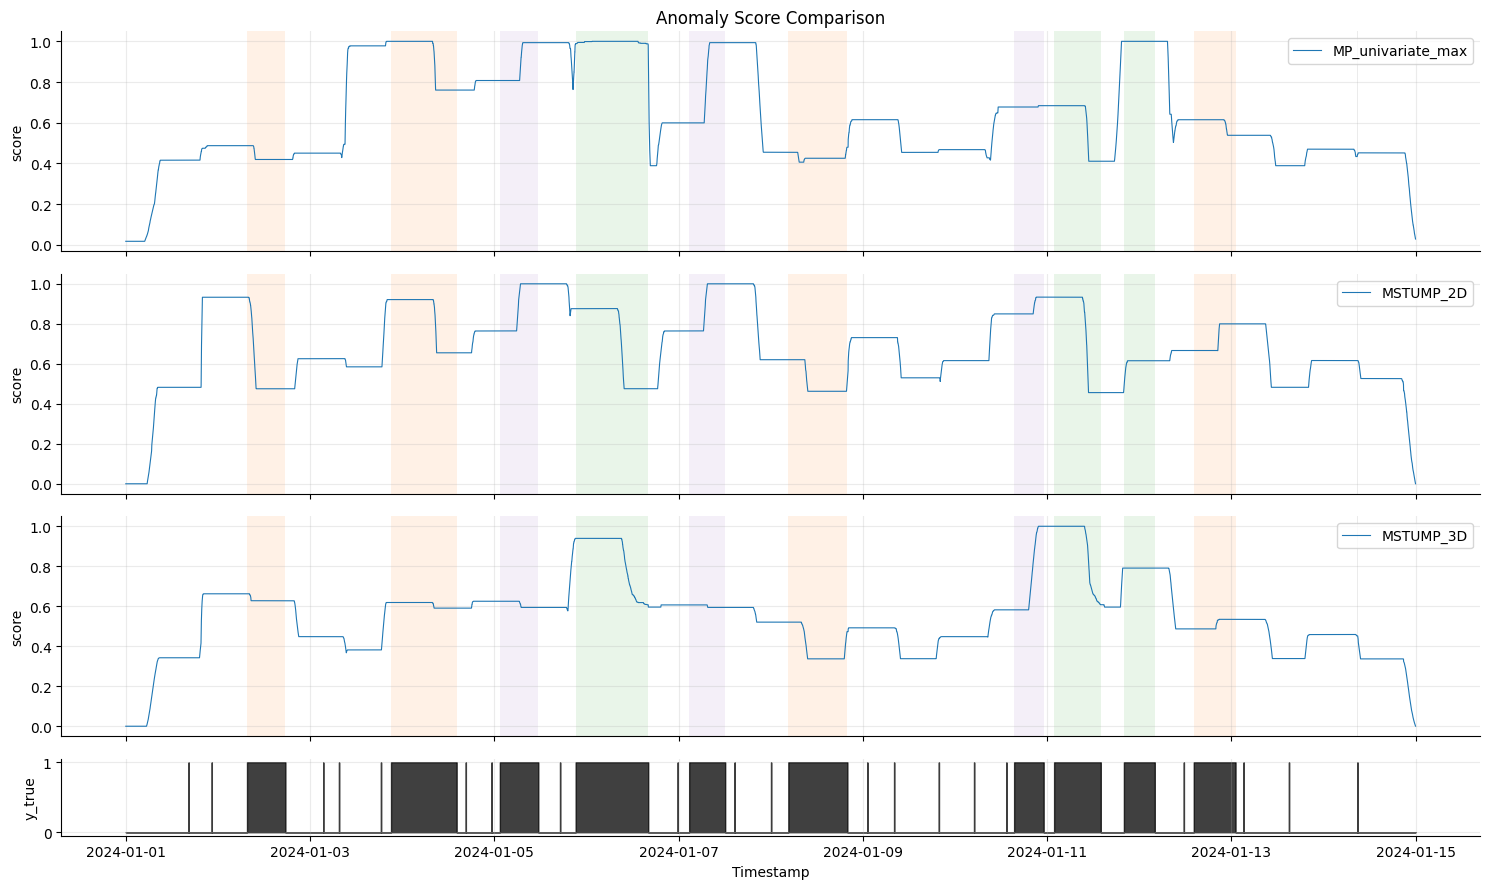

In [12]:
def plot_score_comparison(
    score_df: pd.DataFrame,
    y: np.ndarray,
    metadata: pd.DataFrame,
) -> plt.Figure:
    comparison_columns = [
        ("MP_univariate_max", "score_uni_max"),
        ("MSTUMP_2D", "score_mstump_2d"),
        ("MSTUMP_3D", "score_mstump_3d"),
    ]

    fig, axes = plt.subplots(
        len(comparison_columns) + 1,
        1,
        figsize=(15, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [1] * len(comparison_columns) + [0.35]},
    )

    for ax, (label, column) in zip(axes[:-1], comparison_columns):
        ax.plot(score_df.index, score_df[column], linewidth=0.8, label=label)
        add_all_anomaly_spans(ax, metadata, alpha=0.10)
        ax.set_ylabel("score")
        ax.legend(loc="upper right")

    axes[-1].fill_between(score_df.index, y, step="pre", color="black", alpha=0.75)
    axes[-1].set_yticks([0, 1])
    axes[-1].set_ylabel("y_true")
    axes[-1].set_xlabel("Timestamp")
    axes[0].set_title("Anomaly Score Comparison")

    fig.tight_layout()
    return fig


fig = plot_score_comparison(all_score_df, y_true, anomaly_metadata)
save_figure(fig, "anomaly_score_comparison")
plt.show()


**Visual Comparison of Aggregated Univariate and MSTUMP Scores**

This figure compares the aggregated univariate max score with the 2D and 3D MSTUMP scores. The `MP_univariate_max` score is a simple baseline that becomes high when at least one individual sensor has a high Matrix Profile score. In contrast, MSTUMP computes Matrix Profile scores from multidimensional subsequences.

With \(m = 720\), each score represents a 12-hour subsequence. The plot shows that several longer anomaly intervals coincide with high scores, especially around some multisensor and correlation-breaking events. At the same time, high values also appear in some normal regions. This is expected, because the data has a repeated daily structure and Matrix Profile identifies unusual subsequences, not only the anomalies that were manually injected.

The 2D and 3D MSTUMP profiles are useful because they evaluate combinations of sensors instead of treating each signal independently. Visually, they do not separate every anomaly perfectly, but they provide a direct way to examine whether joint sensor behaviour improves detection.

For this reason, the plot should be used mainly as a qualitative comparison. The final conclusion should be based on the quantitative metrics, especially ROC AUC, PR AUC, precision, recall, and F1-score.

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\roc_curves.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\roc_curves.pdf


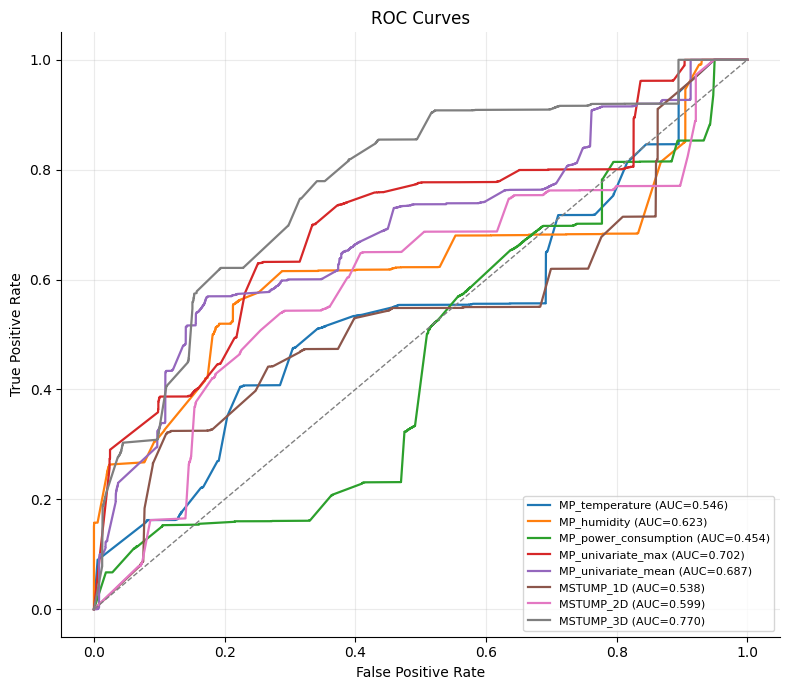

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\precision_recall_curves.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\precision_recall_curves.pdf


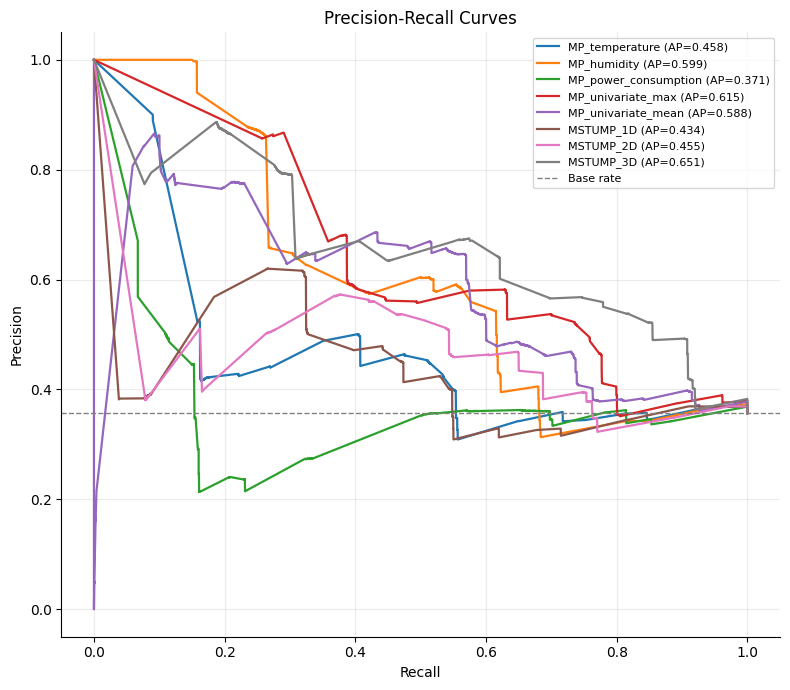

In [13]:
def plot_roc_curves(
    y_true: np.ndarray,
    score_df: pd.DataFrame,
    method_score_columns: dict[str, str],
    results_auc: pd.DataFrame,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(8, 7))
    auc_lookup = results_auc.set_index("method")["roc_auc"].to_dict()

    for idx, (method, column) in enumerate(method_score_columns.items()):
        scores = minmax_normalize(score_df[column].to_numpy())
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax.plot(
            fpr,
            tpr,
            linewidth=1.6,
            label=f"{method} (AUC={auc_lookup[method]:.3f})",
        )

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.0)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves")
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    return fig


def plot_precision_recall_curves(
    y_true: np.ndarray,
    score_df: pd.DataFrame,
    method_score_columns: dict[str, str],
    results_auc: pd.DataFrame,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(8, 7))
    ap_lookup = results_auc.set_index("method")["average_precision_pr_auc"].to_dict()
    base_rate = y_true.mean()

    for method, column in method_score_columns.items():
        scores = minmax_normalize(score_df[column].to_numpy())
        precision, recall, _ = precision_recall_curve(y_true, scores)
        ax.plot(
            recall,
            precision,
            linewidth=1.6,
            label=f"{method} (AP={ap_lookup[method]:.3f})",
        )

    ax.axhline(base_rate, linestyle="--", color="gray", linewidth=1.0, label="Base rate")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curves")
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    return fig


fig = plot_roc_curves(y_true, all_score_df, METHOD_SCORE_COLUMNS, results_auc)
save_figure(fig, "roc_curves")
plt.show()

fig = plot_precision_recall_curves(y_true, all_score_df, METHOD_SCORE_COLUMNS, results_auc)
save_figure(fig, "precision_recall_curves")
plt.show()


**Interpretation of the ROC and Precision-Recall Curves**

The ROC and precision-recall curves compare all Matrix Profile scores used in the experiment: the individual univariate sensor scores, the aggregated univariate baselines, and the MSTUMP profiles.

The best ROC AUC is obtained by `MSTUMP_3D`, which means that the full multidimensional profile ranks anomalous timestamps above normal timestamps better than the other tested methods. The aggregated univariate max score also performs well, showing that simple score fusion is a strong baseline.

The precision-recall curve gives a more useful view for this dataset because the anomaly labels are imbalanced. Again, `MSTUMP_3D` achieves the highest average precision, followed closely by the aggregated univariate max score and the humidity profile. This suggests that using all three sensors together improves the ranking of anomalous timestamps compared with most univariate alternatives.

These results do not mean that MSTUMP is always better for every anomaly type. Some anomalies are still easier to detect from a single sensor, especially when the abnormal behaviour is clearly visible in that variable. However, the strong performance of `MSTUMP_3D` shows that the multidimensional profile captures useful joint behaviour between temperature, humidity, and power consumption.

Overall, the ROC and precision-recall results support the use of MSTUMP in this experiment, especially with the 12-hour window. The results also confirm that the choice of subsequence length is important for Matrix Profile-based anomaly detection.

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\threshold_f1_comparison.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\threshold_f1_comparison.pdf


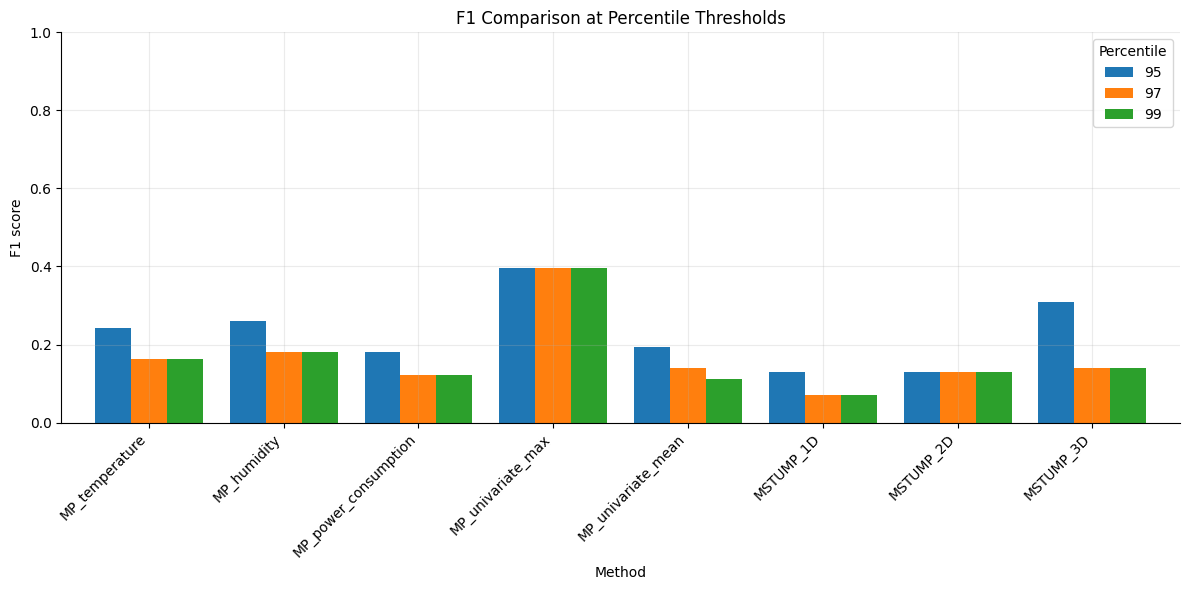

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\per_anomaly_type_detection.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\per_anomaly_type_detection.pdf


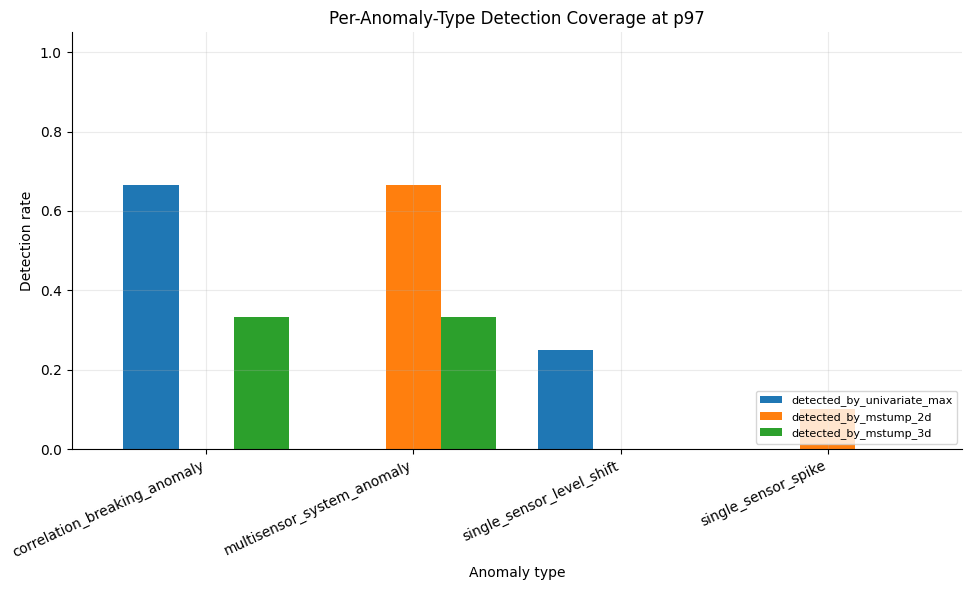

In [14]:
def plot_threshold_f1_comparison(results_thresholds: pd.DataFrame) -> plt.Figure:
    f1_pivot = (
        results_thresholds
        .pivot(index="method", columns="percentile", values="f1")
        .loc[list(METHOD_SCORE_COLUMNS.keys())]
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    f1_pivot.plot(kind="bar", ax=ax, width=0.8)
    ax.set_ylabel("F1 score")
    ax.set_xlabel("Method")
    ax.set_title("F1 Comparison at Percentile Thresholds")
    ax.set_ylim(0.0, 1.0)
    ax.legend(title="Percentile")
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    fig.tight_layout()
    return fig


def plot_per_anomaly_type_detection(coverage_df: pd.DataFrame) -> plt.Figure:
    coverage_columns = [
        "detected_by_univariate_max",
        "detected_by_mstump_2d",
        "detected_by_mstump_3d",
    ]
    plot_df = coverage_df.set_index("anomaly_type")[coverage_columns]

    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df.plot(kind="bar", ax=ax, width=0.8)
    ax.set_ylabel("Detection rate")
    ax.set_xlabel("Anomaly type")
    ax.set_title(f"Per-Anomaly-Type Detection Coverage at p{ANOMALY_TYPE_THRESHOLD_PERCENTILE}")
    ax.set_ylim(0.0, 1.05)
    ax.legend(fontsize=8, loc="lower right")
    ax.tick_params(axis="x", rotation=25)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    fig.tight_layout()
    return fig


fig = plot_threshold_f1_comparison(results_thresholds)
save_figure(fig, "threshold_f1_comparison")
plt.show()

fig = plot_per_anomaly_type_detection(per_anomaly_type_detection)
save_figure(fig, "per_anomaly_type_detection")
plt.show()


**Summary of the Multivariate Matrix Profile Results**

The final metrics show that this is still a challenging detection problem. The dataset contains different anomaly types, including point anomalies, longer level shifts, multisensor system events, and correlation-breaking intervals. Because these anomalies have different durations and behaviours, a single threshold is not expected to work equally well for all cases.

The F1 comparison shows that the aggregated univariate max score performs best at the tested percentile thresholds. This means that a simple rule based on the strongest individual sensor score is still a strong baseline for this dataset.

The MSTUMP results are most useful for understanding multivariate behaviour. The 3D MSTUMP profile uses temperature, humidity, and power consumption together, so it is better aligned with anomalies that affect the joint behaviour of the system. Although it does not achieve the highest F1 score in the threshold-based comparison, it performs better than the lower-dimensional MSTUMP profiles and provides useful information about multidimensional anomaly patterns.

The event-level coverage plot gives a more detailed view. The aggregated univariate max score detects a larger proportion of correlation-breaking anomalies, while MSTUMP 2D and MSTUMP 3D show stronger coverage for multisensor system anomalies. This suggests that different methods respond to different anomaly types. The univariate max score is effective when at least one sensor becomes clearly unusual, while MSTUMP is more relevant when the abnormal behaviour appears across multiple sensors.

Short one-point spikes remain difficult to detect. This is expected because \(m = 720\) corresponds to a 12-hour subsequence, while spike anomalies last only one timestamp. The effect of a very short anomaly can therefore be diluted inside a long subsequence. This does not indicate an implementation problem; it reflects the mismatch between the duration of the anomaly and the selected Matrix Profile window size.

Overall, the multivariate experiment shows that MSTUMP is a useful extension of Matrix Profile for multidimensional IoT monitoring, especially for longer and system-level anomalies. However, it should be interpreted as a complementary method rather than a universal replacement for univariate baselines.

## 10. Export Artifacts

The notebook saves the generated datasets, labels, anomaly metadata, scores, and evaluation tables so that the results can be reused outside the notebook.

All exported CSV files are written to:

```text
outputs/multivariate_mstump/
```

In [15]:
df_normal.to_csv(OUTPUTS_DIR / "dataset_normal.csv", index_label="timestamp")
df_anom.to_csv(OUTPUTS_DIR / "dataset_anomalous.csv", index_label="timestamp")
anomaly_metadata.to_csv(OUTPUTS_DIR / "anomaly_metadata.csv", index=False)
y_true_series.to_csv(OUTPUTS_DIR / "y_true.csv", index_label="timestamp")
results_auc.to_csv(OUTPUTS_DIR / "evaluation_auc.csv", index=False)
results_thresholds.to_csv(OUTPUTS_DIR / "evaluation_thresholds.csv", index=False)
per_anomaly_type_detection.to_csv(
    OUTPUTS_DIR / "per_anomaly_type_detection.csv",
    index=False,
)
all_score_df.to_csv(OUTPUTS_DIR / "anomaly_scores.csv", index_label="timestamp")

print("Saved output artifacts:")
for path in sorted(OUTPUTS_DIR.glob("*.csv")):
    print(f" - {path}")


Saved output artifacts:
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\anomaly_metadata.csv
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\anomaly_scores.csv
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\dataset_anomalous.csv
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\dataset_normal.csv
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\evaluation_auc.csv
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\evaluation_thresholds.csv
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\per_anomaly_type_detection.csv
 - C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\outputs\multivariate_mstump\y_true.csv


## 11. Optional Extra Window Sizes: Window-Size Sensitivity Analysis

The main experiment uses \(m = 720\), which corresponds to 12 hours of data. Since Matrix Profile is a subsequence-based method, the choice of window size is important. A shorter window may be more sensitive to local changes, while a longer window may capture broader operating patterns. At the same time, very long windows can reduce the effect of short anomalies.

To examine the effect of this parameter, the core experiment is also repeated with \(m = 360\) and \(m = 1440\), corresponding to 6-hour and 24-hour subsequences. The 6-hour window provides a comparison with a shorter temporal scale, while the 24-hour window tests whether using a full daily cycle improves detection.

This analysis is used as a sensitivity check rather than as a separate experiment. It helps show whether the performance of the univariate and multidimensional Matrix Profile methods depends on the selected subsequence length.

In [16]:
def run_core_profiles_for_window(
    data_mp_input: pd.DataFrame,
    y_true: np.ndarray,
    m_value: int,
) -> pd.DataFrame:
    temp_score_df = pd.DataFrame(index=data_mp_input.index)

    for sensor in SENSOR_COLUMNS:
        mp = stumpy.stump(data_mp_input[sensor].to_numpy(dtype=np.float64), m=m_value)
        subsequence_profile = np.asarray(mp[:, 0], dtype=float)
        point_scores = subsequence_scores_to_point_scores(
            subsequence_profile,
            m=m_value,
            n_samples=len(data_mp_input),
        )
        temp_score_df[f"score_mp_{sensor}"] = minmax_normalize(point_scores)

    per_sensor_columns = [f"score_mp_{sensor}" for sensor in SENSOR_COLUMNS]
    temp_score_df["score_uni_max"] = temp_score_df[per_sensor_columns].max(axis=1)
    temp_score_df["score_uni_mean"] = temp_score_df[per_sensor_columns].mean(axis=1)

    T_extra = data_mp_input[SENSOR_COLUMNS].to_numpy(dtype=np.float64).T
    P_extra, _ = stumpy.mstump(T_extra, m=m_value)
    for k in range(1, len(SENSOR_COLUMNS) + 1):
        point_scores = subsequence_scores_to_point_scores(
            np.asarray(P_extra[k - 1], dtype=float),
            m=m_value,
            n_samples=len(data_mp_input),
        )
        temp_score_df[f"score_mstump_{k}d"] = minmax_normalize(point_scores)

    window_results = evaluate_threshold_free(
        y_true,
        temp_score_df,
        METHOD_SCORE_COLUMNS,
    )
    window_results.insert(0, "m", m_value)
    return window_results


if RUN_EXTRA_WINDOWS:
    extra_results = []
    for m_extra in EXTRA_WINDOW_SIZES:
        print(f"Running optional Matrix Profile experiment for m={m_extra}...")
        extra_results.append(run_core_profiles_for_window(df_mp_input, y_true, m_extra))

    results_extra_windows = pd.concat(extra_results, ignore_index=True)
    results_extra_windows.to_csv(
        OUTPUTS_DIR / "evaluation_extra_windows_auc.csv",
        index=False,
    )
    display(results_extra_windows)
else:
    print("RUN_EXTRA_WINDOWS is False. Optional m=720 and m=1440 runs were skipped.")


Running optional Matrix Profile experiment for m=360...
Running optional Matrix Profile experiment for m=1440...


,m,method,roc_auc,average_precision_pr_auc
0,360,MP_humidity,0.501337,0.487531
1,360,MSTUMP_3D,0.512082,0.429225
2,360,MP_univariate_max,0.514881,0.390938
3,360,MP_univariate_mean,0.479182,0.387305
4,360,MSTUMP_2D,0.462080,0.369744
5,360,MP_power_consumption,0.474741,0.354918
6,360,MSTUMP_1D,0.435343,0.324553
7,360,MP_temperature,0.446998,0.317478
8,1440,MSTUMP_3D,0.729387,0.573383
9,1440,MP_univariate_mean,0.727446,0.561611


,m,method,roc_auc,average_precision_pr_auc
0,360,MP_humidity,0.501337,0.487531
1,360,MP_power_consumption,0.474741,0.354918
2,360,MP_temperature,0.446998,0.317478
3,360,MP_univariate_max,0.514881,0.390938
4,360,MP_univariate_mean,0.479182,0.387305
5,360,MSTUMP_1D,0.435343,0.324553
6,360,MSTUMP_2D,0.462080,0.369744
7,360,MSTUMP_3D,0.512082,0.429225
8,720,MP_humidity,0.623188,0.599090
9,720,MP_power_consumption,0.454411,0.371063


Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\window_size_roc_auc_comparison.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\window_size_roc_auc_comparison.pdf


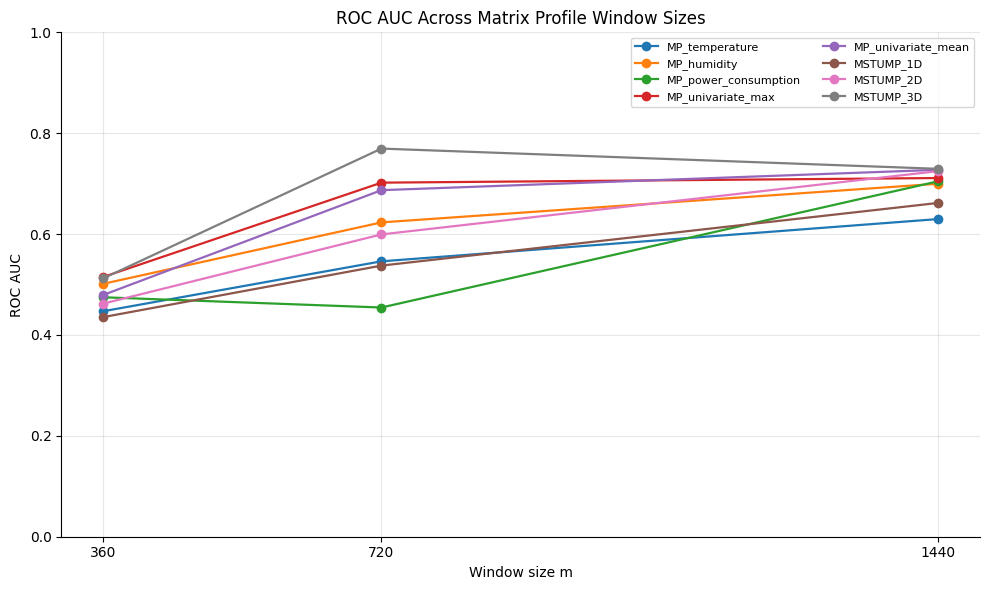

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\window_size_pr_auc_comparison.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\window_size_pr_auc_comparison.pdf


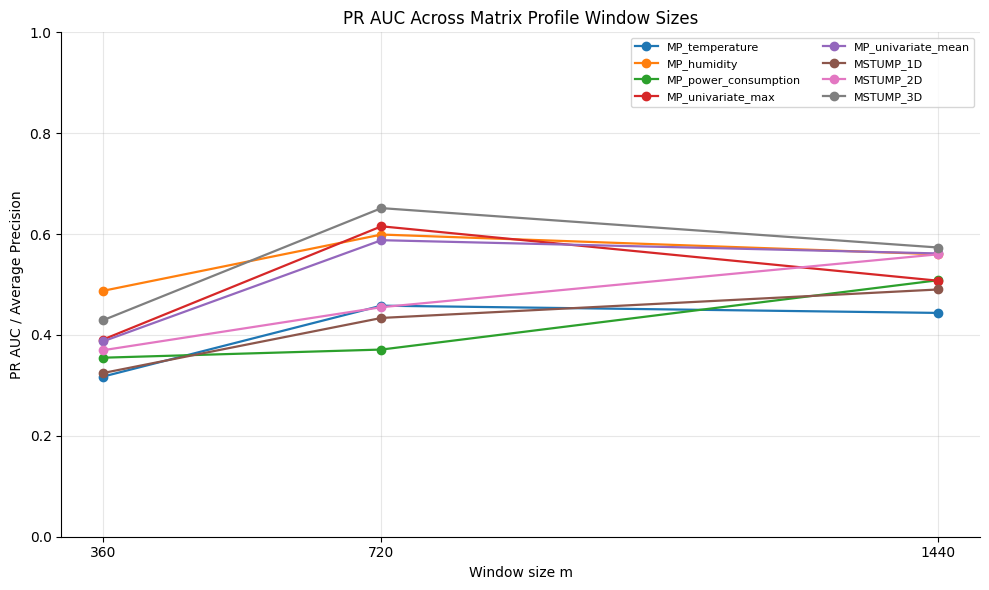

Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\mstump_window_size_sensitivity.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\mstump_window_size_sensitivity.pdf


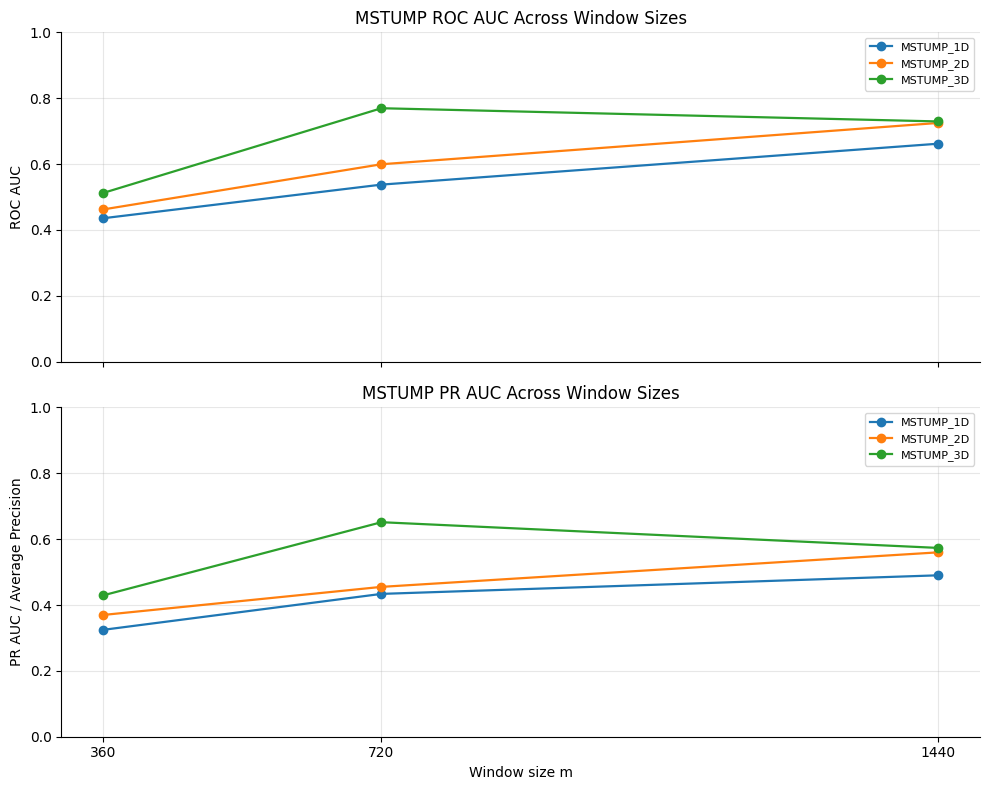

Best method per window based on PR AUC:


,m,method,roc_auc,average_precision_pr_auc
0,360,MP_humidity,0.501337,0.487531
1,720,MSTUMP_3D,0.769515,0.651484
2,1440,MSTUMP_3D,0.729387,0.573383


Best method per window based on ROC AUC:


,m,method,roc_auc,average_precision_pr_auc
0,360,MP_univariate_max,0.514881,0.390938
1,720,MSTUMP_3D,0.769515,0.651484
2,1440,MSTUMP_3D,0.729387,0.573383


Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\pr_auc_by_method_and_window_size.png
Saved: C:\Users\stavp\Desktop\Stavroula\Msc\Thesis\Datasets\NAB Dataset\plots\multivariate_mstump\pr_auc_by_method_and_window_size.pdf


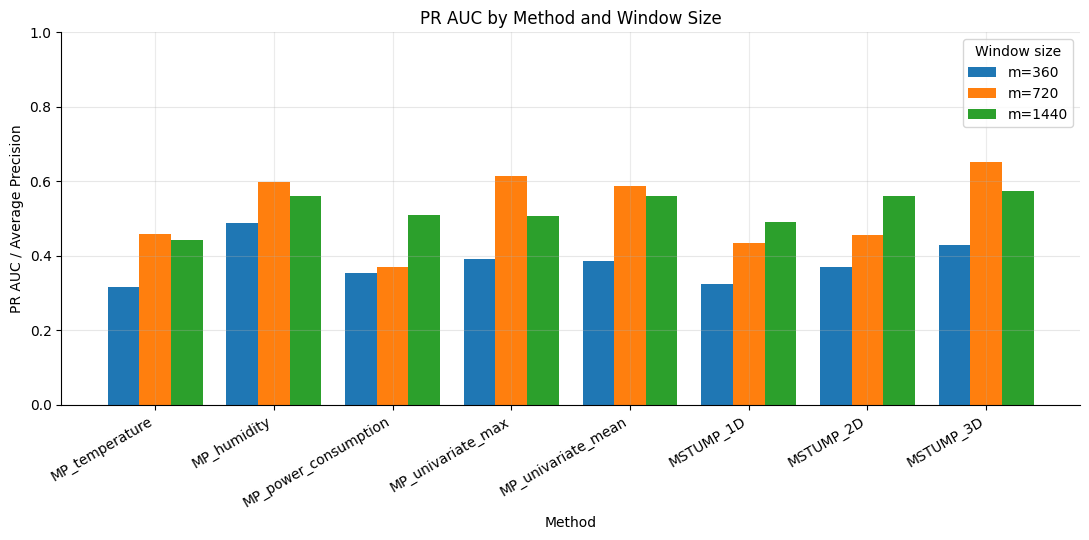

In [17]:
# -------------------------------------------------------------------------
# Prepare optional window-size results for plotting
# -------------------------------------------------------------------------

# If the main m=720 results were not included in results_extra_windows,
# combine them with the optional m=360 and m=1440 results.
main_window_auc = results_auc.copy()
main_window_auc.insert(0, "m", WINDOW_SIZE_MAIN)

if "results_extra_windows" in globals():
    window_auc_results = pd.concat(
        [main_window_auc, results_extra_windows],
        ignore_index=True,
    )
else:
    window_auc_results = main_window_auc.copy()

# Remove possible duplicates if m=7200 was already included.
window_auc_results = (
    window_auc_results
    .drop_duplicates(subset=["m", "method"], keep="last")
    .sort_values(["m", "method"])
    .reset_index(drop=True)
)

display(window_auc_results)

# -------------------------------------------------------------------------
# Plot ROC AUC by window size
# -------------------------------------------------------------------------

def plot_window_size_metric(
    results_df: pd.DataFrame,
    metric: str,
    title: str,
    ylabel: str,
    filename: str,
) -> plt.Figure:
    """
    Plot a threshold-free metric across different Matrix Profile window sizes.
    """

    fig, ax = plt.subplots(figsize=(10, 6))

    method_order = [
        "MP_temperature",
        "MP_humidity",
        "MP_power_consumption",
        "MP_univariate_max",
        "MP_univariate_mean",
        "MSTUMP_1D",
        "MSTUMP_2D",
        "MSTUMP_3D",
    ]

    for method in method_order:
        method_df = results_df[results_df["method"] == method].sort_values("m")

        if method_df.empty:
            continue

        ax.plot(
            method_df["m"],
            method_df[metric],
            marker="o",
            linewidth=1.6,
            label=method,
        )

    ax.set_title(title)
    ax.set_xlabel("Window size m")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(results_df["m"].unique()))
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8, ncol=2)

    fig.tight_layout()
    save_figure(fig, filename)

    return fig


fig = plot_window_size_metric(
    results_df=window_auc_results,
    metric="roc_auc",
    title="ROC AUC Across Matrix Profile Window Sizes",
    ylabel="ROC AUC",
    filename="window_size_roc_auc_comparison",
)

plt.show()


fig = plot_window_size_metric(
    results_df=window_auc_results,
    metric="average_precision_pr_auc",
    title="PR AUC Across Matrix Profile Window Sizes",
    ylabel="PR AUC / Average Precision",
    filename="window_size_pr_auc_comparison",
)

plt.show()


# -------------------------------------------------------------------------
# Focused plot: MSTUMP methods only
# -------------------------------------------------------------------------

def plot_mstump_window_sensitivity(
    results_df: pd.DataFrame,
) -> plt.Figure:
    """
    Plot ROC AUC and PR AUC across window sizes for MSTUMP only.
    """

    mstump_methods = ["MSTUMP_1D", "MSTUMP_2D", "MSTUMP_3D"]
    mstump_df = results_df[results_df["method"].isin(mstump_methods)].copy()

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 8),
        sharex=True,
    )

    for method in mstump_methods:
        method_df = mstump_df[mstump_df["method"] == method].sort_values("m")

        axes[0].plot(
            method_df["m"],
            method_df["roc_auc"],
            marker="o",
            linewidth=1.6,
            label=method,
        )

        axes[1].plot(
            method_df["m"],
            method_df["average_precision_pr_auc"],
            marker="o",
            linewidth=1.6,
            label=method,
        )

    axes[0].set_title("MSTUMP ROC AUC Across Window Sizes")
    axes[0].set_ylabel("ROC AUC")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc="best", fontsize=8)

    axes[1].set_title("MSTUMP PR AUC Across Window Sizes")
    axes[1].set_xlabel("Window size m")
    axes[1].set_ylabel("PR AUC / Average Precision")
    axes[1].set_xticks(sorted(mstump_df["m"].unique()))
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="best", fontsize=8)

    fig.tight_layout()
    save_figure(fig, "mstump_window_size_sensitivity")

    return fig


fig = plot_mstump_window_sensitivity(window_auc_results)
plt.show()

# -------------------------------------------------------------------------
# Best method per window size
# -------------------------------------------------------------------------

best_by_window_pr = (
    window_auc_results
    .sort_values(["m", "average_precision_pr_auc", "roc_auc"], ascending=[True, False, False])
    .groupby("m", as_index=False)
    .first()
)

best_by_window_roc = (
    window_auc_results
    .sort_values(["m", "roc_auc", "average_precision_pr_auc"], ascending=[True, False, False])
    .groupby("m", as_index=False)
    .first()
)

print("Best method per window based on PR AUC:")
display(best_by_window_pr)

print("Best method per window based on ROC AUC:")
display(best_by_window_roc)


# -------------------------------------------------------------------------
# Bar plot: PR AUC per method grouped by window size
# -------------------------------------------------------------------------

def plot_pr_auc_grouped_by_window(
    results_df: pd.DataFrame,
) -> plt.Figure:
    """
    Plot PR AUC for each method grouped by Matrix Profile window size.
    """

    method_order = [
        "MP_temperature",
        "MP_humidity",
        "MP_power_consumption",
        "MP_univariate_max",
        "MP_univariate_mean",
        "MSTUMP_1D",
        "MSTUMP_2D",
        "MSTUMP_3D",
    ]

    pivot = results_df.pivot(
        index="method",
        columns="m",
        values="average_precision_pr_auc",
    )

    pivot = pivot.loc[[m for m in method_order if m in pivot.index]]

    fig, ax = plt.subplots(figsize=(11, 5.5))

    x = np.arange(len(pivot.index))
    windows = list(pivot.columns)
    width = 0.8 / len(windows)

    for i, window in enumerate(windows):
        ax.bar(
            x + i * width - (width * (len(windows) - 1) / 2),
            pivot[window],
            width=width,
            label=f"m={window}",
        )

    ax.set_title("PR AUC by Method and Window Size")
    ax.set_xlabel("Method")
    ax.set_ylabel("PR AUC / Average Precision")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=30, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Window size")

    fig.tight_layout()
    save_figure(fig, "pr_auc_by_method_and_window_size")

    return fig


fig = plot_pr_auc_grouped_by_window(window_auc_results)
plt.show()



**Interpretation of the Window-Size Sensitivity Analysis**

The sensitivity analysis shows that the subsequence length has a strong effect on the Matrix Profile results. This is expected because Matrix Profile does not score individual points directly. Instead, each score is based on subsequences of length \(m\), so the selected window should be related to the expected duration of the abnormal patterns.

The results show a clear improvement when moving from \(m = 360\) to \(m = 720\). This is visible in both ROC AUC and PR AUC for several methods. The 12-hour window appears to match the duration of the longer injected anomalies better than the 6-hour window, especially for level shifts, multisensor system events, and correlation-breaking intervals.

The 24-hour window, \(m = 1440\), also improves performance for some methods, but it is not consistently better than \(m = 720\). This suggests that a full daily-cycle window can be useful, but it may also dilute anomalies that last less than one full day.

For MSTUMP, the 3D profile is the strongest multidimensional result across the tested window sizes. It performs especially well at \(m = 720\), which supports using the full combination of temperature, humidity, and power consumption in the main multivariate experiment.

Based on this analysis, \(m = 720\) is selected as the main window size for the final experiment. The comparison with \(m = 360\) and \(m = 1440\) is kept as a sensitivity check, showing that the performance of Matrix Profile-based anomaly detection depends strongly on the choice of subsequence length.